# Two Steps MultiFidelity Neural Network

Code to show the performance of the Neural Network when dealing with different LF datasets 

In [1]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from time import perf_counter
import pandas as pd
import pickle
import os
import keras
import tensorflow as tf
import sys
from utils.network_utils import *
from utils.functions_to_ray import *
from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)



True

In [2]:
# reproducibility
seed = 42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

## Data Preparation

In [3]:
# import of the discretization and diffusion parameter values
Discretizations= np.loadtxt(
    "../DATA_reaction_diffusion_test_case/Discretizations.txt"
).astype(
    int
)[::-1]

diffusion= np.loadtxt(
    "../DATA_reaction_diffusion_test_case/diffusion.txt"
).astype(
    int
)

In [4]:
# introduction of the high fidelity part of the dataset
file_path_HF = "../DATA_reaction_diffusion_test_case/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)

# I consider only the reaction term as a variable
U_HF_test = U_HF_test[:, -1, 44,44]
# normalization of the data
reaction_HF_test = normalization(reaction_HF_test)
U_HF_test=normalization(U_HF_test)

# transformation of the dataseet
reaction_HF_test_original=np.c_[reaction_HF_test, np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0]-5*np.pi/6))]
U_HF_test_original=U_HF_test

In [5]:
# data augmentation introducing a noise
noise_stddev1=[0.01,0.005,0.02,0.005]
noise_stddev2=[0.005,0.003,0.01,0.003]

(U_HF_test,reaction_HF_test)=add_noise(noise_stddev1,noise_stddev2,reaction_HF_test,U_HF_test.reshape(-1,1))
reaction_HF_test=np.c_[reaction_HF_test, np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0]-5*np.pi/6))]

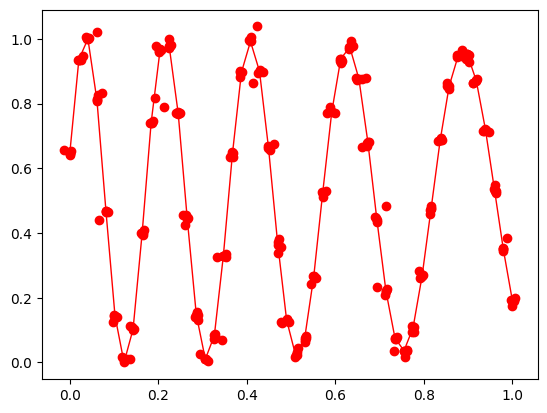

In [6]:
# plot of the new dataset
plt.plot(reaction_HF_test[:,0], U_HF_test, "ro", linewidth=1, label="HF model with noise")
plt.plot(reaction_HF_test_original[:,0], U_HF_test_original, "r-", linewidth=1, label="HF model")
plt.show()

In [7]:
# Number of data of High and Low Fidelity components of the dataset
n_HF = np.array([100])
Nlf = np.array([200])
n_per=np.array([150])
batch_size=[200,150, 100]


In [8]:
U_LF_list = []
U_HF_list = []
# number of epochs 
Nepo=[7000,1500,8000]

# NepoLF = 7000  # number of epochs for first NN: NN_LF
# NepoHF = 8000  # number of epochs for second NN: NN_HF

r2_HF_df = pd.DataFrame(columns=['Discretization','Diffusion','R2'])  # dataframe which stores HF R^2
r2_LF_df = pd.DataFrame(columns=['Discretization','Diffusion','R2'])  # dataframe which stores LF R^2
r2_Lin_df = pd.DataFrame(columns=['Discretization','Diffusion','R2'])
mse_HF_df = pd.DataFrame(columns=['Discretization','Diffusion','MSE'])  # dataframe which stores HF MSE
mse_LF_df = pd.DataFrame(columns=['Discretization','Diffusion','MSE'])  # dataframe which stores LF MSE
mse_Lin_df = pd.DataFrame(columns=['Discretization','Diffusion','MSE'])

## Neural Network
Cycle on the Discretization and the value of the diffusion 

******** # Nb. nodes = 46 ********
******** # Diff: = 75 ********
******** # NHF: = 100 ********
******** # Nper: = 150 ********
******** # NLF: = 200 ********


[I 2024-08-21 14:39:55,356] A new study created in RDB with name: no-name-3131beaa-3a54-4d6a-82dc-d15beb4f976e
[I 2024-08-21 14:49:58,822] Trial 1 finished with value: 0.11781014964427577 and parameters: {'nodes': 16, 'l2weight': 0.008406400727372719, 'lr': 0.007828777908975303, 'kernel_init': 'uniform', 'opt': 'Adamax'}. Best is trial 1 with value: 0.11781014964427577.
[I 2024-08-21 14:50:00,847] Trial 0 finished with value: 0.14470594113624702 and parameters: {'nodes': 4, 'l2weight': 0.0105992668536596, 'lr': 0.05398250924060092, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 1 with value: 0.11781014964427577.
[I 2024-08-21 14:50:01,665] Trial 9 finished with value: 0.11729430384066211 and parameters: {'nodes': 36, 'l2weight': 0.019960410785060032, 'lr': 0.00042136949699828676, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 9 with value: 0.11729430384066211.
[I 2024-08-21 14:50:02,364] Trial 10 finished with value: 0.10164238110447363 and parameter

New parameters identified during HPO:
{'kernel_init': 'glorot_uniform',
 'l2weight': 0.055687407222784514,
 'lr': 0.013763036873234191,
 'nodes': 15,
 'opt': 'Adam'}
The function training took 167.944700 seconds.


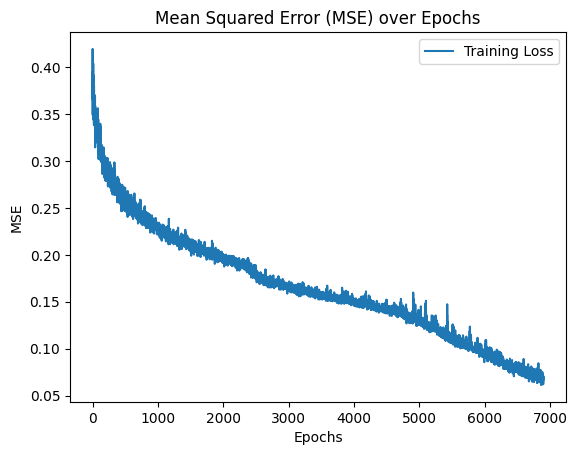

[I 2024-08-21 15:07:25,199] A new study created in RDB with name: no-name-844d653a-84ce-4762-90c5-0a399fb38447
[I 2024-08-21 15:09:23,015] Trial 7 finished with value: 0.04955704937482321 and parameters: {'nodes': 34, 'l2weight': 0.004184919889013838, 'lr': 0.00013171469052692105, 'kernel_init': 'uniform', 'opt': 'Adamax'}. Best is trial 7 with value: 0.04955704937482321.
[I 2024-08-21 15:09:23,938] Trial 4 finished with value: 0.007205382638328441 and parameters: {'nodes': 8, 'l2weight': 0.00024178842835963538, 'lr': 0.00606825709250152, 'kernel_init': 'uniform', 'opt': 'Adam'}. Best is trial 4 with value: 0.007205382638328441.
[I 2024-08-21 15:09:24,854] Trial 0 finished with value: 0.009813617179160971 and parameters: {'nodes': 19, 'l2weight': 0.00019277349478885632, 'lr': 0.00281415461363016, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 4 with value: 0.007205382638328441.
[I 2024-08-21 15:09:50,067] Trial 10 finished with value: 0.006283668824529581 and paramete

New parameters identified during HPO:
{'kernel_init': 'uniform',
 'l2weight': 0.00019723116196368882,
 'lr': 0.08155671235896393,
 'nodes': 7,
 'opt': 'Adamax'}
The function training took 34.891293 seconds.


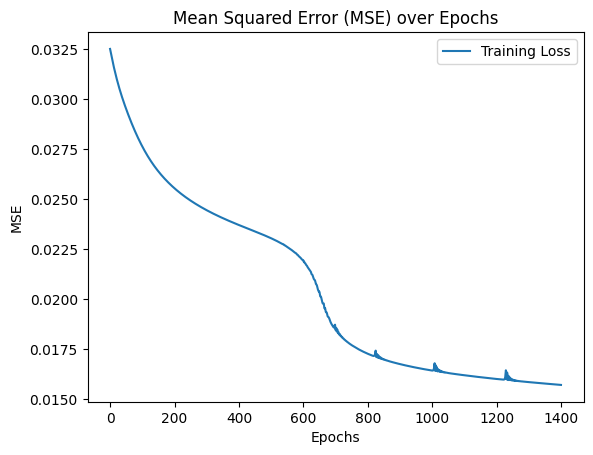

[I 2024-08-21 15:13:17,464] A new study created in RDB with name: no-name-874e67b3-486f-486e-8ea4-0be639883010
[I 2024-08-21 15:24:09,599] Trial 8 finished with value: 0.017217497942370413 and parameters: {'nodes': 6, 'l2weight': 0.0001626350948469608, 'lr': 0.0027442003287306664, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 8 with value: 0.017217497942370413.
[I 2024-08-21 15:24:10,627] Trial 1 finished with value: 0.01800412793804109 and parameters: {'nodes': 15, 'l2weight': 0.018285609376275713, 'lr': 0.011634740659138089, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 8 with value: 0.017217497942370413.
[I 2024-08-21 15:24:16,920] Trial 4 finished with value: 0.06430197604225556 and parameters: {'nodes': 4, 'l2weight': 0.0775274196791378, 'lr': 0.00029345221888871795, 'kernel_init': 'glorot_uniform', 'opt': 'Adam'}. Best is trial 8 with value: 0.017217497942370413.
[I 2024-08-21 15:24:22,015] Trial 7 finished with value: 0.01688288253784921 and

New parameters identified during HPO:
{'kernel_init': 'uniform',
 'l2weight': 0.00014981392074368653,
 'lr': 0.020280502294291045,
 'nodes': 14,
 'opt': 'Adamax'}
The function training took 186.973720 seconds.


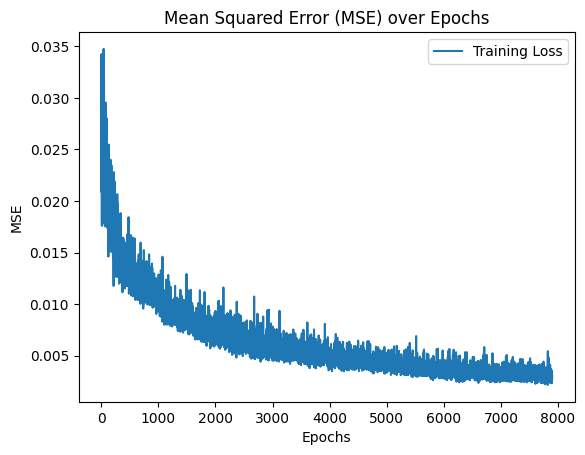

Empty DataFrame
Columns: [Discretization, Diffusion, R2]
Index: []
Empty DataFrame
Columns: [Discretization, Diffusion, MSE]
Index: []


In [11]:
# Initialize variables
m = 0
d = 2

test_mse_HF_list = []
test_mse_LF_list = []
test_mse_per_list = []

r2_HF_list = []
r2_LF_list = []
r2_per_list = []

# Loop through parameters
for nhf in n_HF:
    for nlf in Nlf:
        for nper in n_per:

            # Print current configuration
            print(f"******** # Nb. nodes = {Discretizations[m]} ********")
            print(f"******** # Diff: = {diffusion[d]} ********")
            print(f"******** # NHF: = {nhf} ********")
            print(f"******** # Nper: = {nper} ********")
            print(f"******** # NLF: = {nlf} ********")
            
            # Import Low Fidelity data
            file_path_LF = f"../DATA_reaction_diffusion_test_case/reaction_diffusion_LF_{Discretizations[m]}_d{diffusion[d]}.mat"
            reaction_LF_test, U_LF_test = import_data(file_path_LF)

            # Normalize and select specific data points
            U_LF_test = U_LF_test[:, -1, int(4*(Discretizations[m]-1)/9), int(4*(Discretizations[m]-1)/9)]
            U_LF_test = normalization(U_LF_test)
            reaction_LF_test = normalization(reaction_LF_test)
            
            # Transform Low Fidelity dataset
            reaction_LF_test_original = np.c_[reaction_LF_test, np.abs(np.sin(5 * np.pi * reaction_LF_test[:, 0] - 5 * np.pi / 6))]
            U_LF_test_original = U_LF_test  # Keep original for later use
            
            # Data augmentation with noise
            noise_std1 = [0.02, 0.01, 0.02, 0.01]
            noise_std2 = [0.01, 0.005, 0.01, 0.005]
            U_LF_test, reaction_LF_test = add_noise(noise_std1, noise_std2, reaction_LF_test, U_LF_test.reshape(-1,1))
            
            # Prepare datasets for training and validation
            reaction_LF, U_train_LF = select_random_data(reaction_LF_test, U_LF_test, nlf)
            reaction_per, U_train_per = select_random_data(reaction_HF_test, U_HF_test, nper)
            reaction_HF, U_HF = select_random_data(reaction_HF_test, U_HF_test, nhf)

            # Transform datasets for training
            reaction_LF = augment_with_sin(reaction_LF)
            reaction_LF_test = augment_with_sin(reaction_LF_test)

            # Prepare validation datasets
            reaction_HF_val, U_HF_val = select_random_data(reaction_HF_test, U_HF_test, nhf)
            reaction_per_val, U_per_val = select_random_data(reaction_HF_test, U_HF_test, nper)
            reaction_LF_val, U_train_LF_val = select_random_data(reaction_LF_test, U_LF_test, nlf)

            # Transform validation dataset
            reaction_LF_val = augment_with_sin(reaction_LF_val)
            
            ########################## Neural Network ##########################
            K.clear_session()

            # Define and train the Multifidelity network
            model_definition = {
                "network_type": "3step",
                "names": ["LF", "Hfper", "HF"],
                "data_train": [reaction_LF, reaction_per, reaction_HF],
                "output_train": [U_train_LF, U_train_per, U_HF],
                "data_val": [reaction_LF_val, reaction_per_val, reaction_HF_val],
                "output_val": [U_train_LF_val, U_per_val, U_HF_val],
                "N": Nepo,
                "n": batch_size,
                "train": True,
                "do_HPO": True,
                "verbose": False
            }
            model = NetworkFactory.build_network(**model_definition)

            # # Evaluate and plot results for each network stage
            # evaluate_and_plot_network_1(model, reaction_LF_test_original, U_LF_test_original, reaction_LF, U_train_LF, test_mse_LF_list, r2_LF_list)
            # evaluate_and_plot_network_2(model, reaction_HF_test_original, U_HF_test_original, reaction_HF, U_HF, input_per_train, test_mse_per_list, r2_per_list)
            # evaluate_and_plot_network_3(model, reaction_HF_test_original, U_HF_test_original, reaction_HF, U_HF, input_HF_train, test_mse_HF_list, r2_HF_list)
            # Evaluate and plot results for each network stage


# Print final results
print(r2_HF_df.round(5))
print(mse_HF_df.round(5))



Folder '3_step_models' already exists.
********************  # Nb. nodes = 46  ********************
********************  # Diff: = 0  ********************
********************  # NHF: = 100  ********************
********************  # Nper: = 150  ********************
********************  # NLF: = 200  ********************
The function training took 215.880714 seconds.


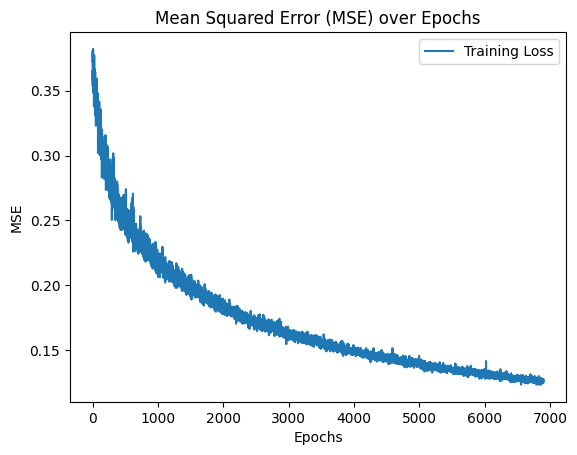

The function training took 34.709807 seconds.


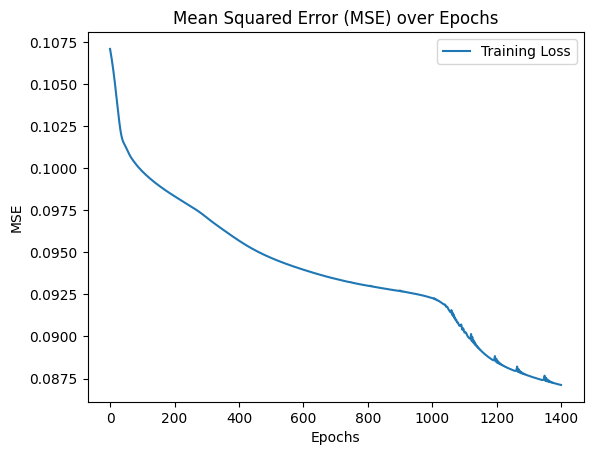

The function training took 185.825869 seconds.


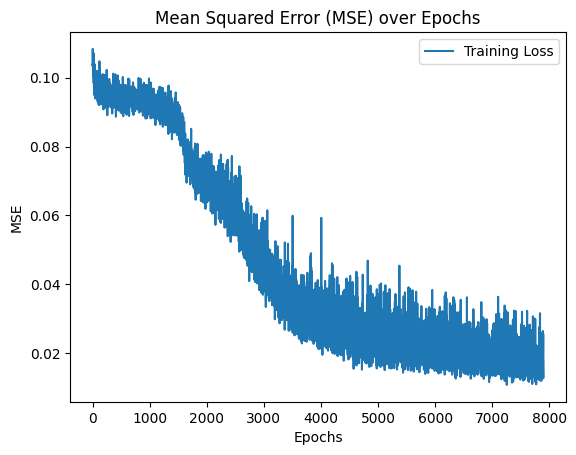

Low Fidelity NN
Test MSE: 0.08760610704386021
R^2: 0.29680063100137866


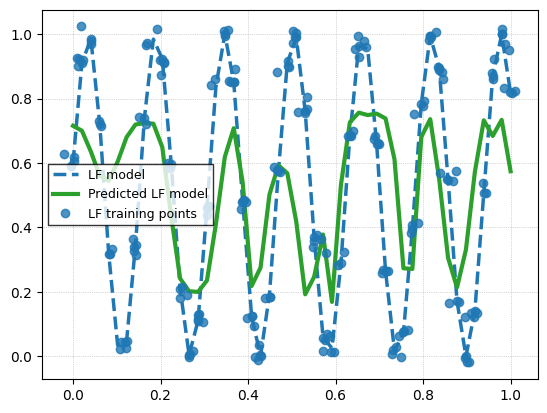

Second model
Test MSE: 0.08769788639118917
R^2: 0.22527538749146936


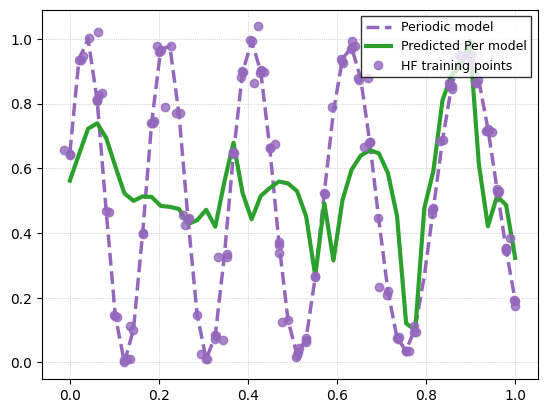

Third model
Test MSE: 0.018591871885455632
R^2: 0.835759089129941


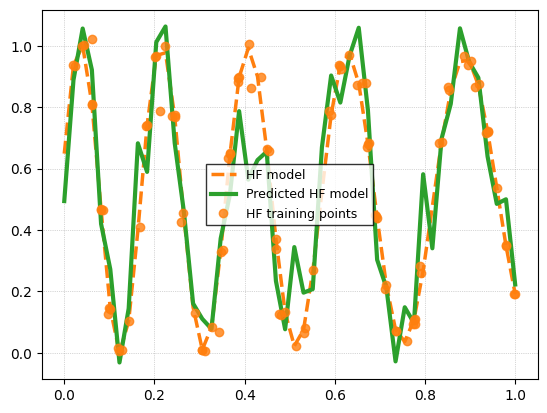

c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\module_utils.py:162: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat([df, pd.DataFrame([new_entry])], ignore_index=True)
c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\module_utils.py:162: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat([df, pd.DataFrame([new_entry])], ignore_index=True)
c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\module_utils.py:162: Future

Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\3_step_models\46_model_0.keras
Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\3_step_models\46_model_1.keras
Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\3_step_models\46_model_2.keras
********************  # Nb. nodes = 46  ********************
********************  # Diff: = 5  ********************
********************  # NHF: = 100  ********************
********************  # Nper: = 150  ********************
********************  # NLF: = 200  ********************
The function training took 159.986542 seconds.


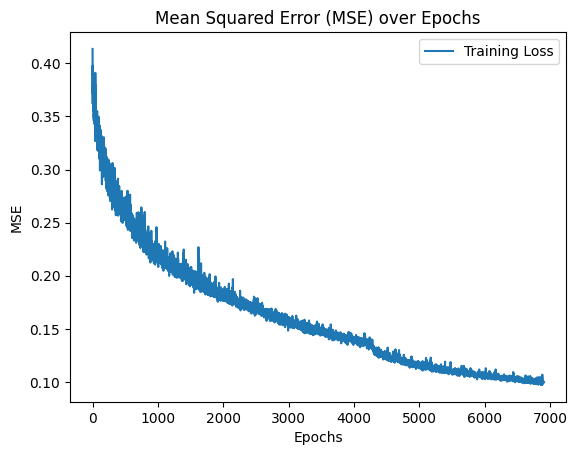

The function training took 33.999212 seconds.


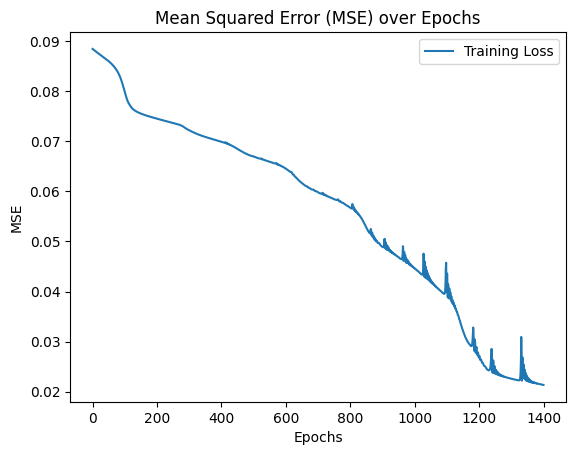

The function training took 175.353602 seconds.


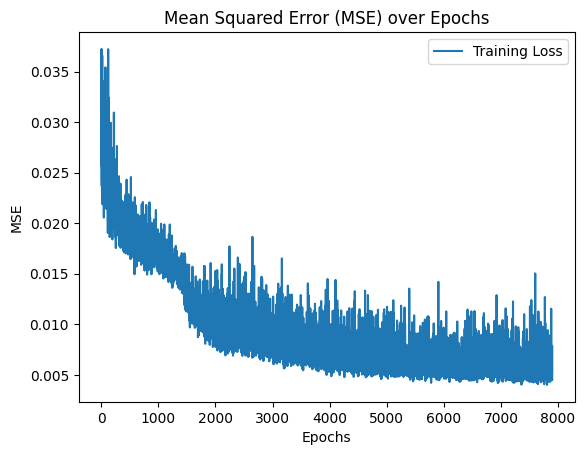

Low Fidelity NN
Test MSE: 0.05501166148927962
R^2: 0.5164304062126635


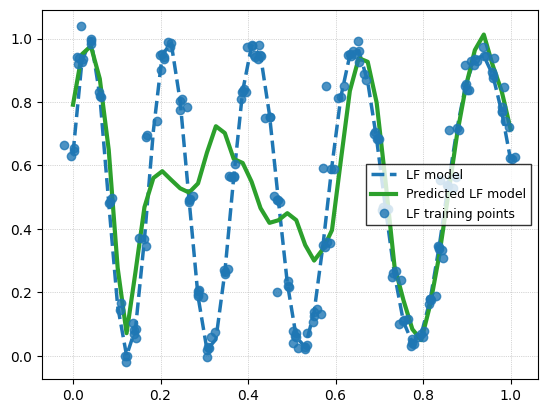

Second model
Test MSE: 0.01593439460973787
R^2: 0.859235288356648


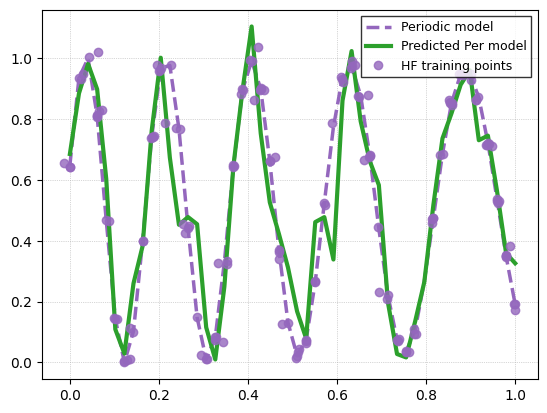

Third model
Test MSE: 0.012532378216804337
R^2: 0.8892887587448225


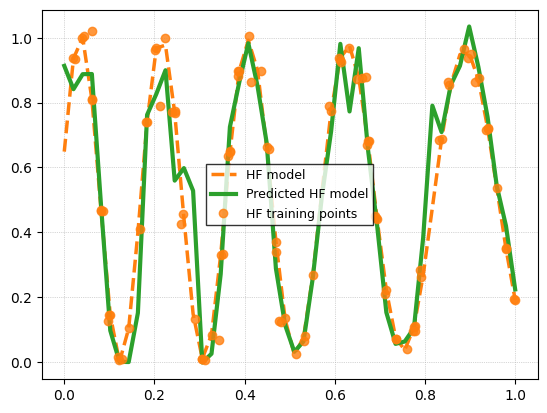

Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\3_step_models\46_model_0.keras
Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\3_step_models\46_model_1.keras
Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\3_step_models\46_model_2.keras
********************  # Nb. nodes = 46  ********************
********************  # Diff: = 75  ********************
********************  # NHF: = 100  ********************
********************  # Nper: = 150  ********************
********************  # NLF: = 200  ********************
The function training took 159.897832 seconds.


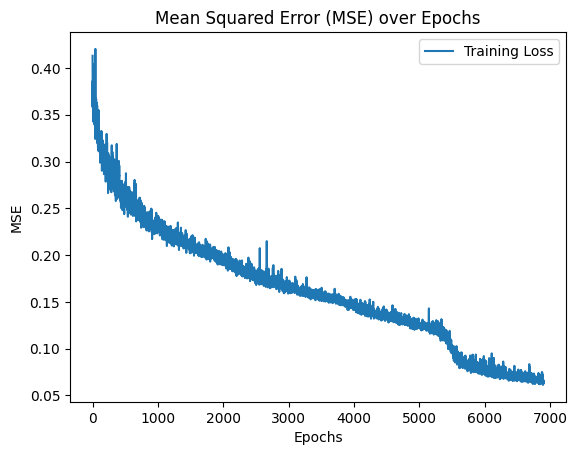

The function training took 37.487533 seconds.


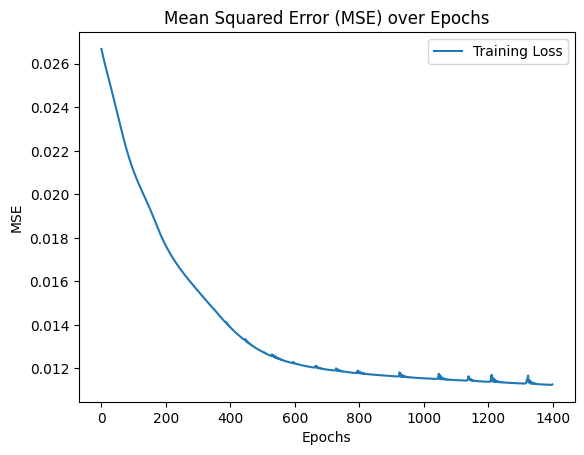

The function training took 198.324435 seconds.


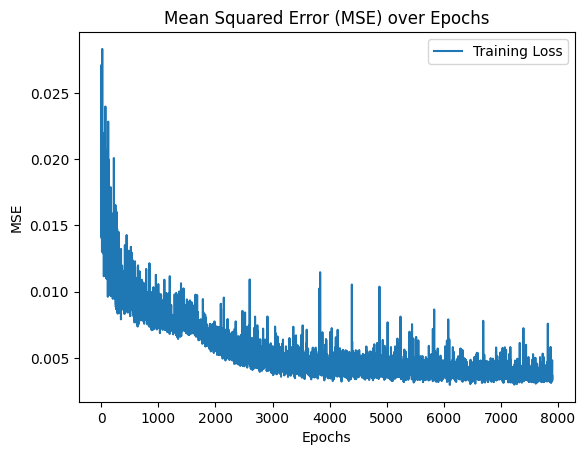

Low Fidelity NN
Test MSE: 0.012763973670967568
R^2: 0.8916362293190411


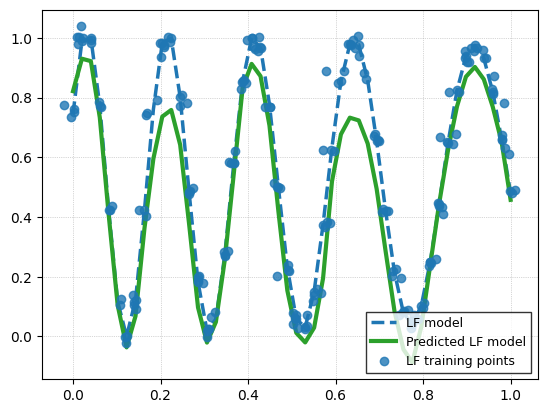

Second model
Test MSE: 0.007754158806602221
R^2: 0.931499629877305


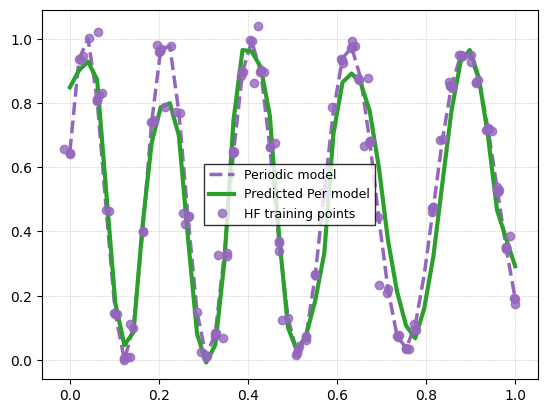

Third model
Test MSE: 0.005801097927831476
R^2: 0.9487530027324033


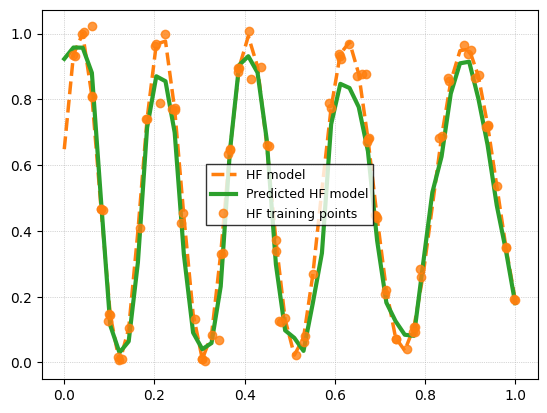

Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\3_step_models\46_model_0.keras
Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\3_step_models\46_model_1.keras
Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\3_step_models\46_model_2.keras
********************  # Nb. nodes = 46  ********************
********************  # Diff: = 1  ********************
********************  # NHF: = 100  ********************
********************  # Nper: = 150  ********************
********************  # NLF: = 200  ********************
The function training took 156.094468 seconds.


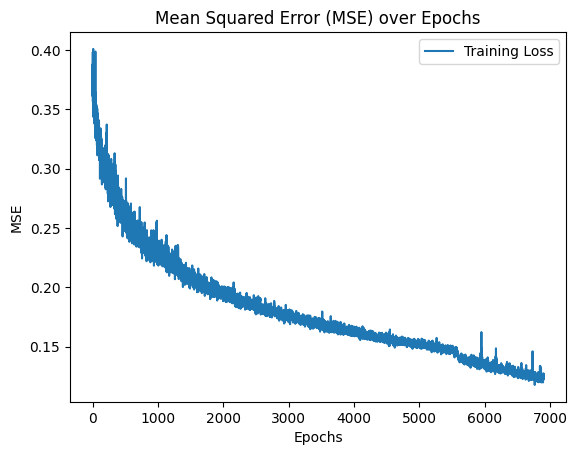

The function training took 32.542919 seconds.


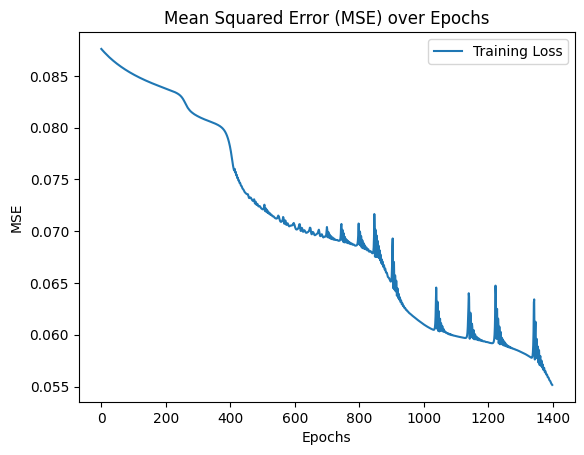

The function training took 173.560775 seconds.


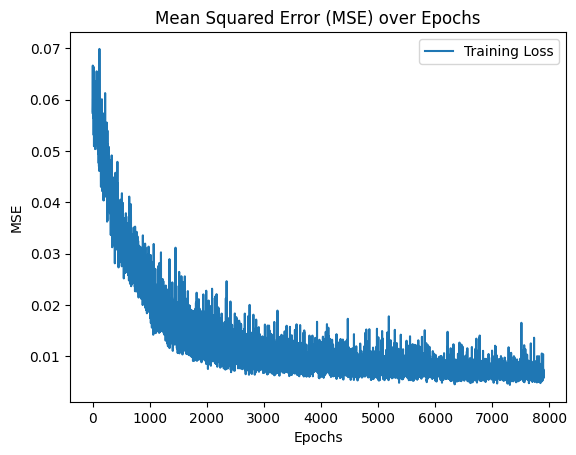

Low Fidelity NN
Test MSE: 0.07723999840232072
R^2: 0.33272829975163876


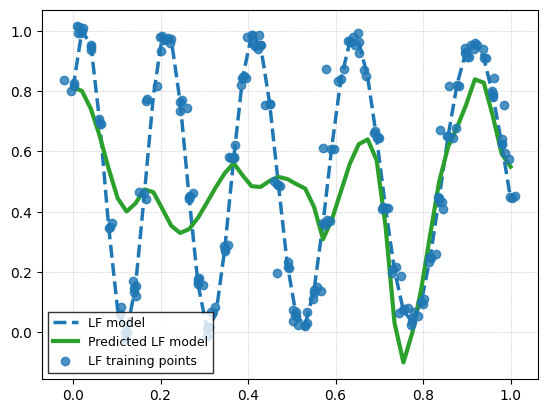

Second model
Test MSE: 0.04815141471555551
R^2: 0.574629587526819


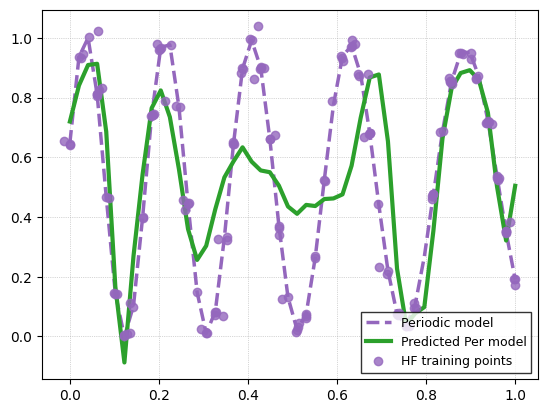

Third model
Test MSE: 0.007524324062949942
R^2: 0.9335299938922683


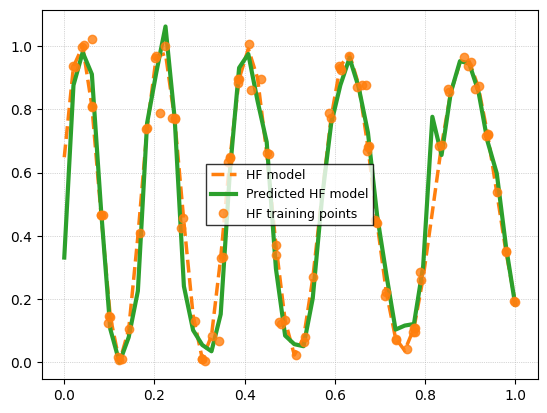

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 0  ********************
********************  # NHF: = 100  ********************
********************  # Nper: = 150  ********************
********************  # NLF: = 200  ********************
The function training took 156.369158 seconds.


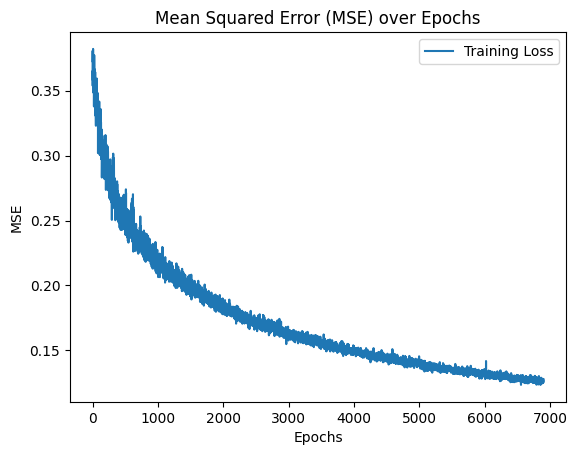

The function training took 33.531652 seconds.


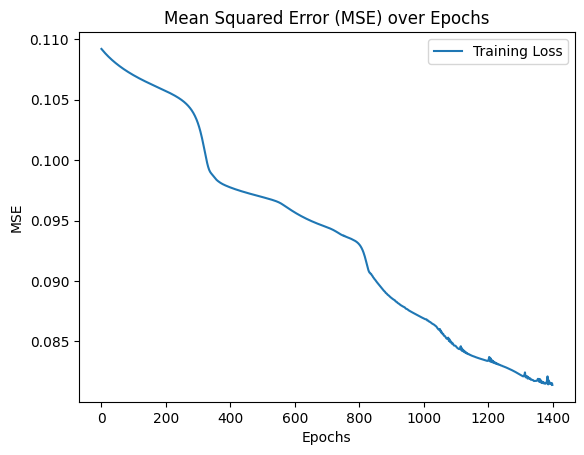

The function training took 171.083691 seconds.


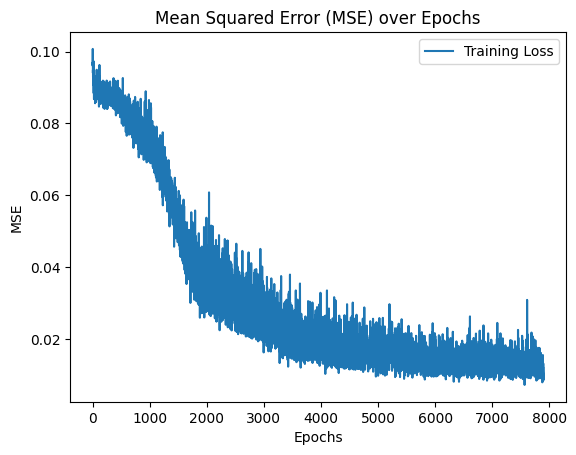

Low Fidelity NN
Test MSE: 0.08788236170682427
R^2: 0.2948562835036159


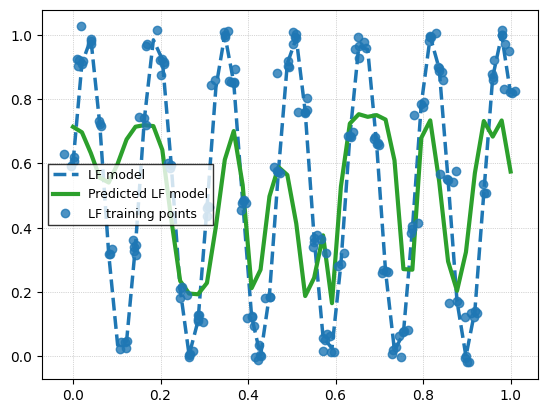

Second model
Test MSE: 0.08457961544353117
R^2: 0.2528222458141993


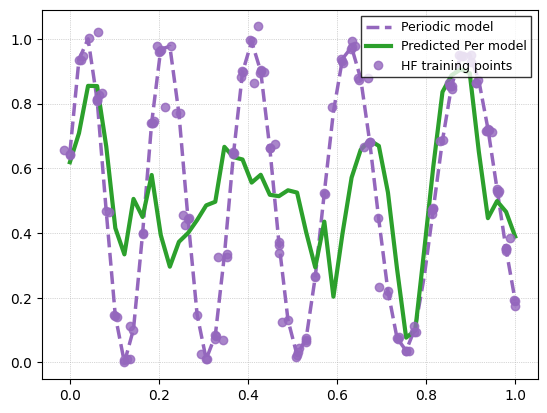

Third model
Test MSE: 0.03422702994364428
R^2: 0.6976378382470144


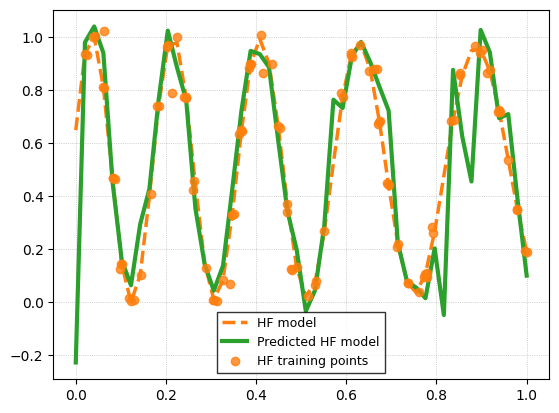

Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\3_step_models\28_model_0.keras
Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\3_step_models\28_model_1.keras
Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\3_step_models\28_model_2.keras
********************  # Nb. nodes = 28  ********************
********************  # Diff: = 5  ********************
********************  # NHF: = 100  ********************
********************  # Nper: = 150  ********************
********************  # NLF: = 200  ********************
The function training took 157.003252 seconds.


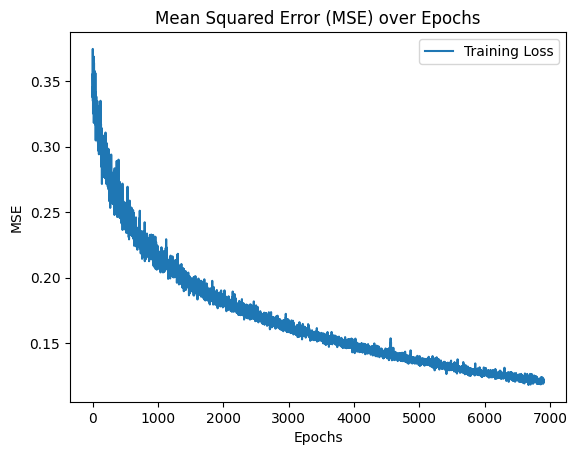

The function training took 32.073904 seconds.


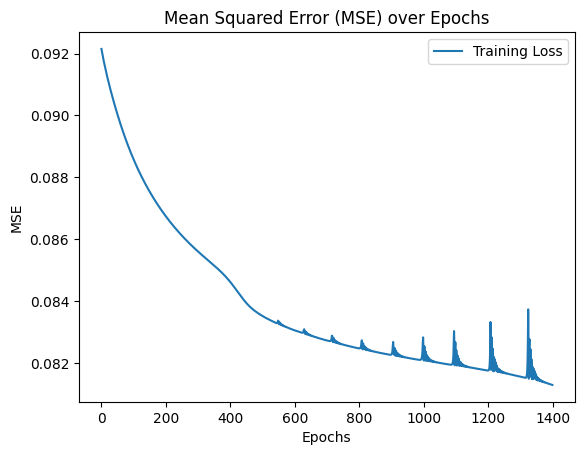

The function training took 169.408545 seconds.


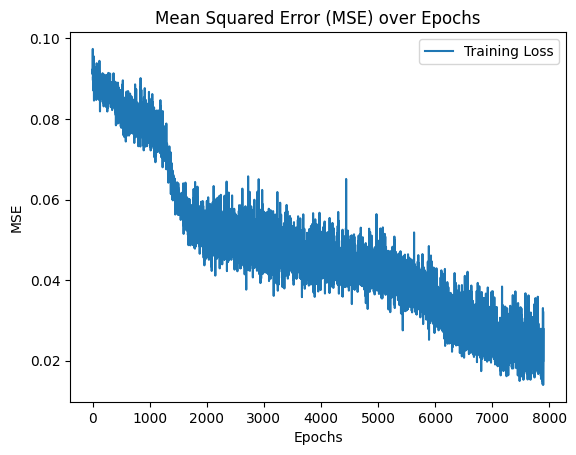

Low Fidelity NN
Test MSE: 0.07815789008951732
R^2: 0.3099095911985097


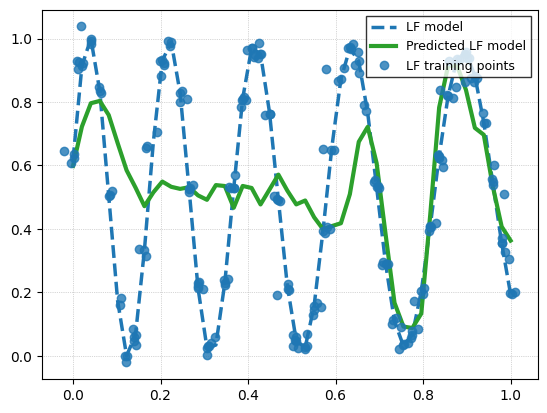

Second model
Test MSE: 0.08029669368828218
R^2: 0.29065764908080516


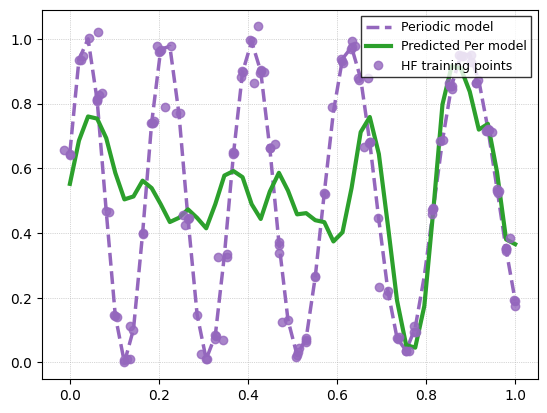

Third model
Test MSE: 0.04844362439209017
R^2: 0.5720482022991893


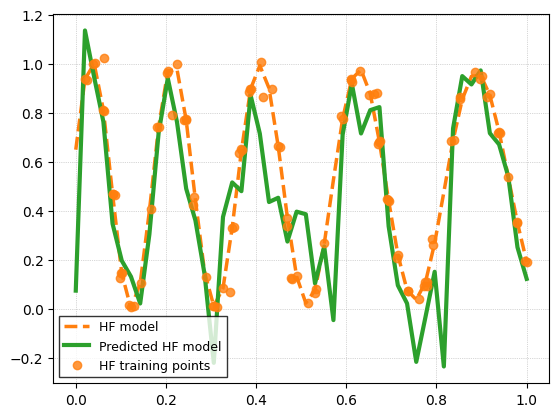

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 75  ********************
********************  # NHF: = 100  ********************
********************  # Nper: = 150  ********************
********************  # NLF: = 200  ********************
The function training took 154.794653 seconds.


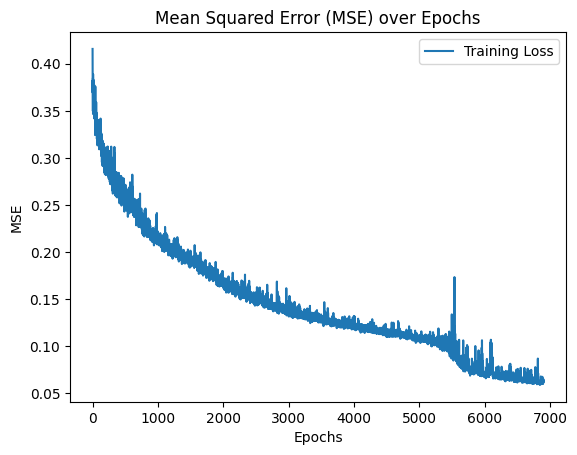

The function training took 32.491282 seconds.


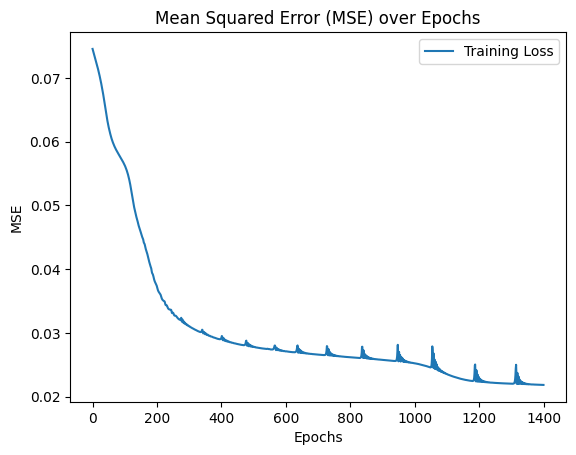

The function training took 168.652666 seconds.


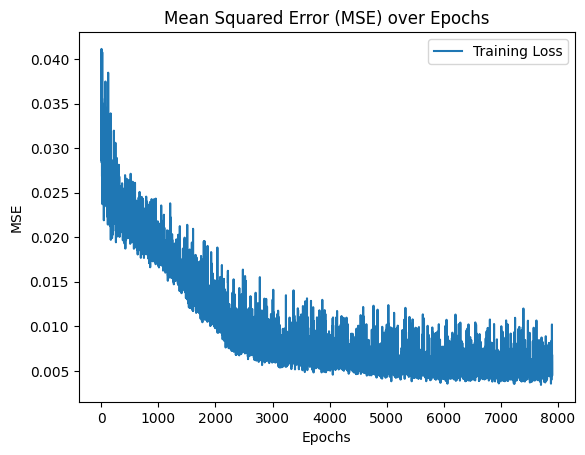

Low Fidelity NN
Test MSE: 0.002346407215268101
R^2: 0.9800436001553547


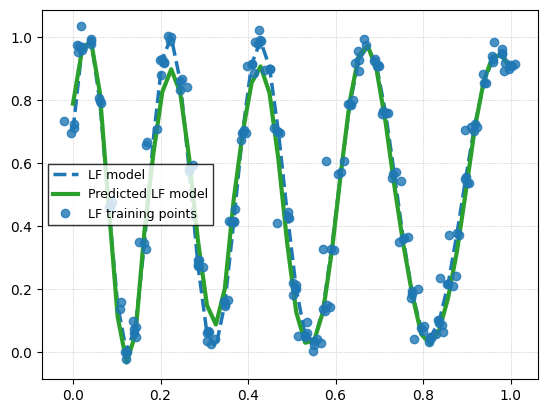

Second model
Test MSE: 0.01833542732325551
R^2: 0.8380245247322792


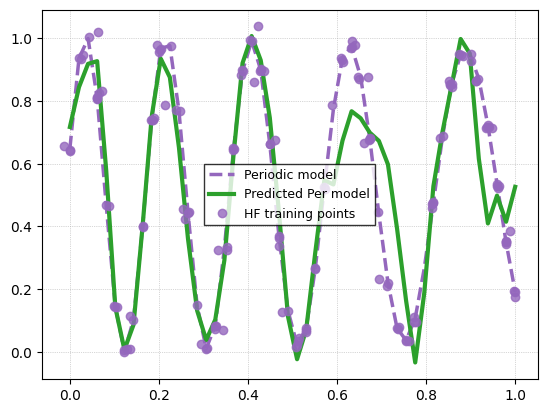

Third model
Test MSE: 0.0075411632242833836
R^2: 0.9333812364560762


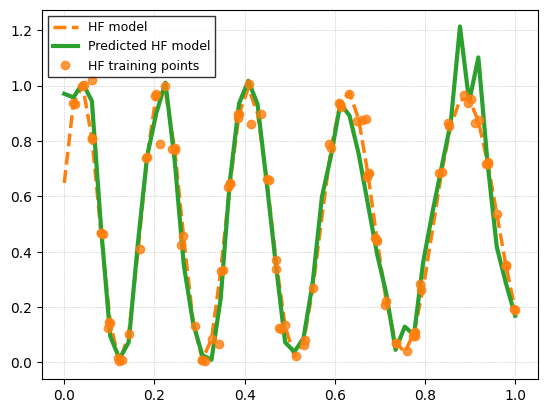

Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\3_step_models\28_model_0.keras
Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\3_step_models\28_model_1.keras
Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\3_step_models\28_model_2.keras
********************  # Nb. nodes = 28  ********************
********************  # Diff: = 1  ********************
********************  # NHF: = 100  ********************
********************  # Nper: = 150  ********************
********************  # NLF: = 200  ********************
The function training took 158.204007 seconds.


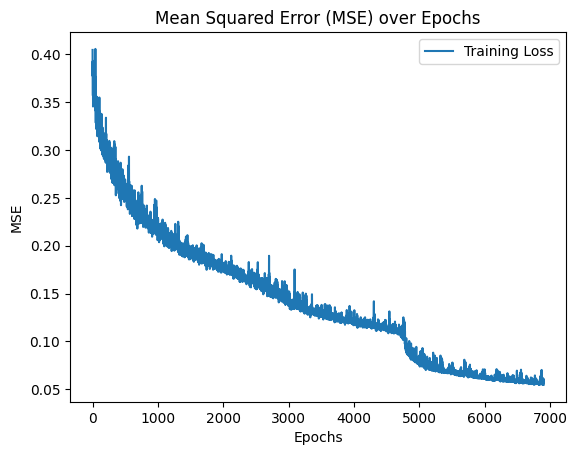

The function training took 37.319186 seconds.


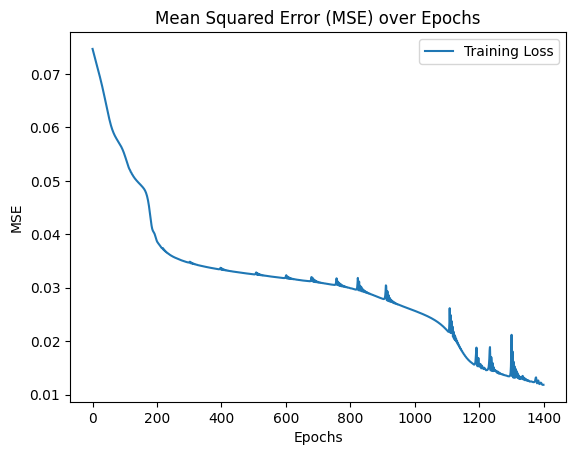

The function training took 191.150820 seconds.


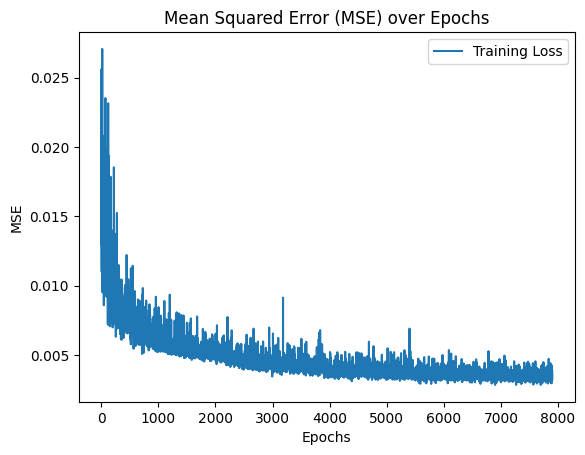

Low Fidelity NN
Test MSE: 0.002578172869835283
R^2: 0.978196556941323


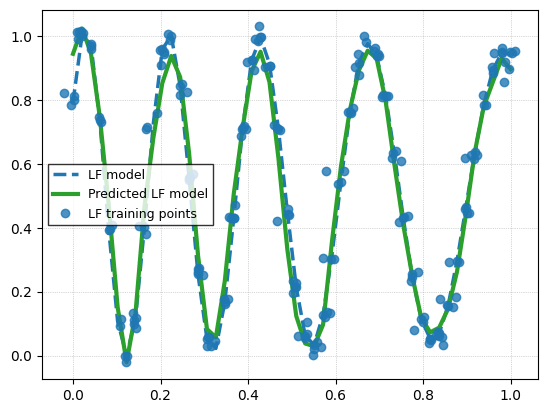

Second model
Test MSE: 0.006362969189654266
R^2: 0.9437894224968016


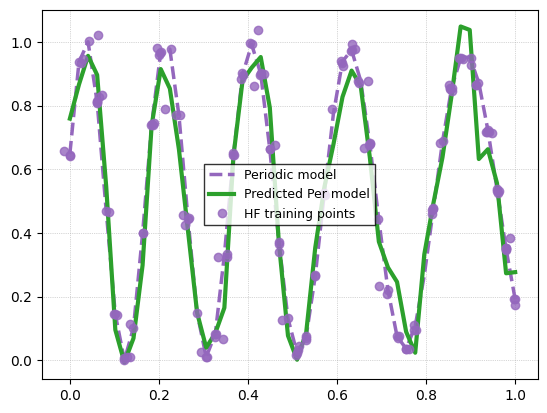

Third model
Test MSE: 0.003564521516603812
R^2: 0.9685109565992157


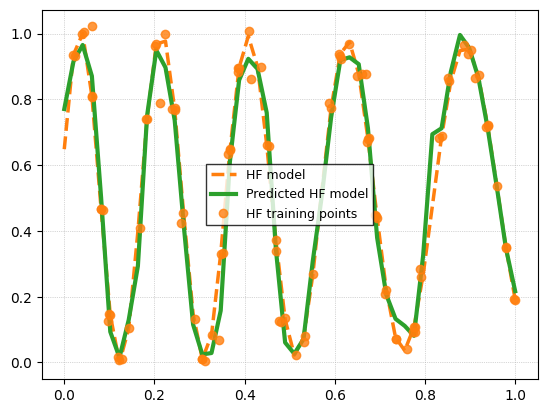

Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\3_step_models\28_model_0.keras
Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\3_step_models\28_model_1.keras
Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\3_step_models\28_model_2.keras
********************  # Nb. nodes = 10  ********************
********************  # Diff: = 0  ********************
********************  # NHF: = 100  ********************
********************  # Nper: = 150  ********************
********************  # NLF: = 200  ********************
The function training took 182.320399 seconds.


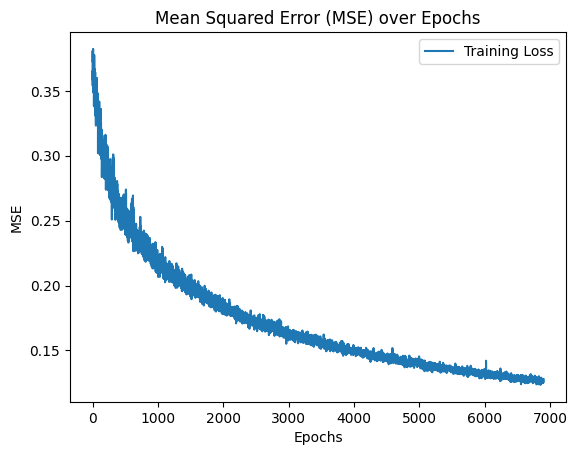

The function training took 32.595491 seconds.


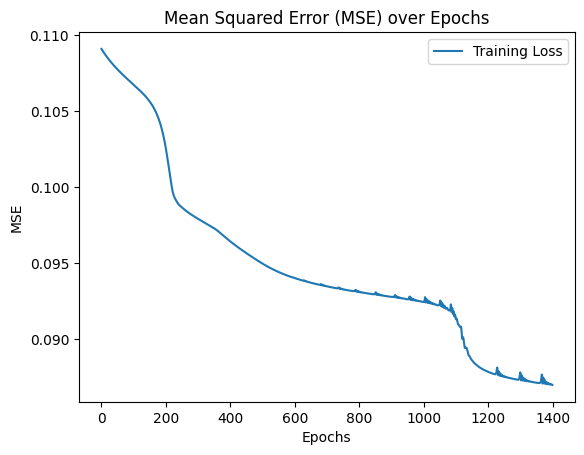

The function training took 182.637919 seconds.


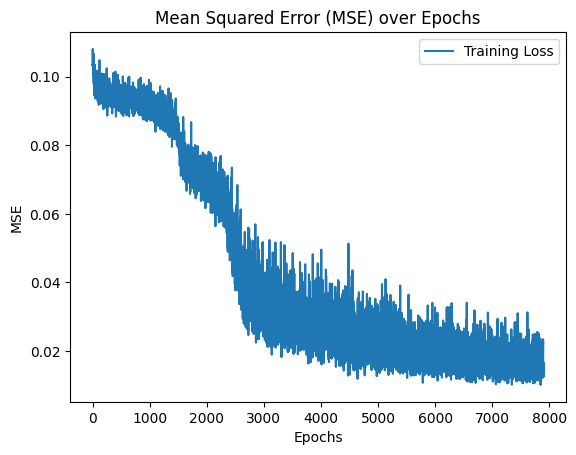

Low Fidelity NN
Test MSE: 0.08775629339791052
R^2: 0.2960973811643657


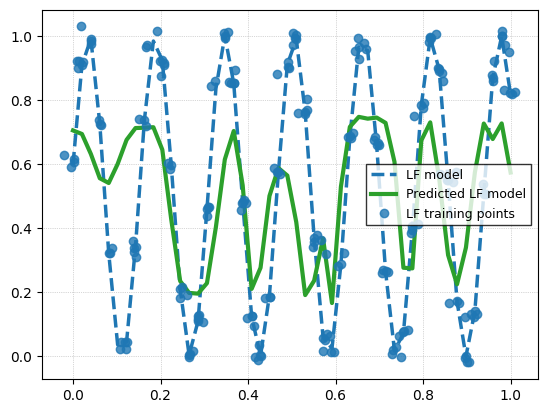

Second model
Test MSE: 0.08713289884343299
R^2: 0.230266497049744


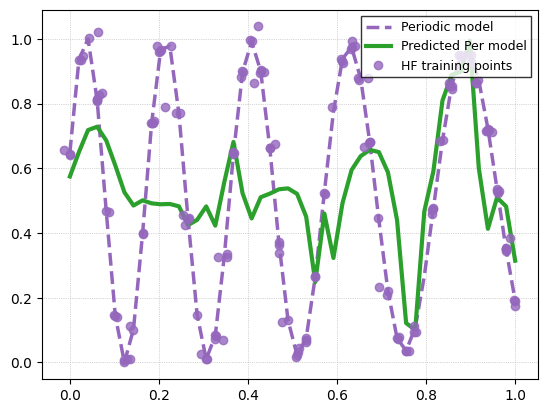

Third model
Test MSE: 0.04658353280271206
R^2: 0.5884802828784553


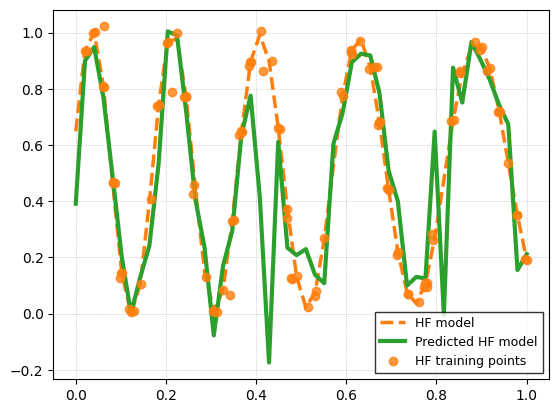

Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\3_step_models\10_model_0.keras
Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\3_step_models\10_model_1.keras
Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\3_step_models\10_model_2.keras
********************  # Nb. nodes = 10  ********************
********************  # Diff: = 5  ********************
********************  # NHF: = 100  ********************
********************  # Nper: = 150  ********************
********************  # NLF: = 200  ********************
The function training took 166.533303 seconds.


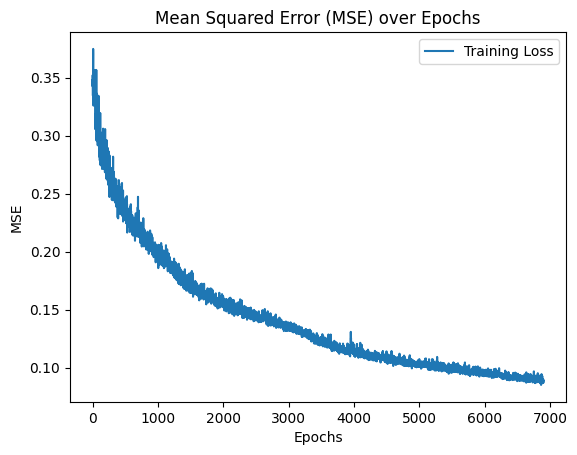

The function training took 35.752176 seconds.


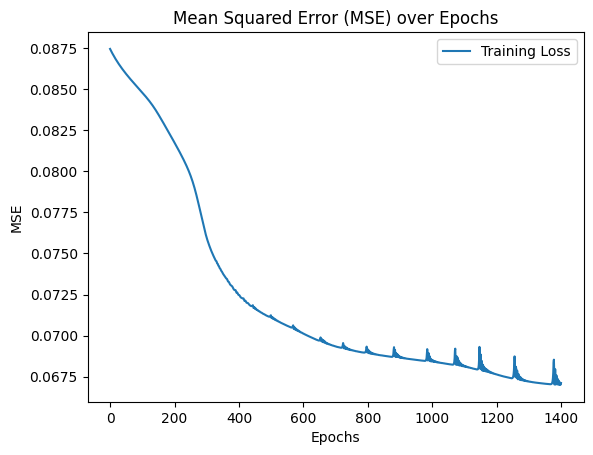

The function training took 173.217878 seconds.


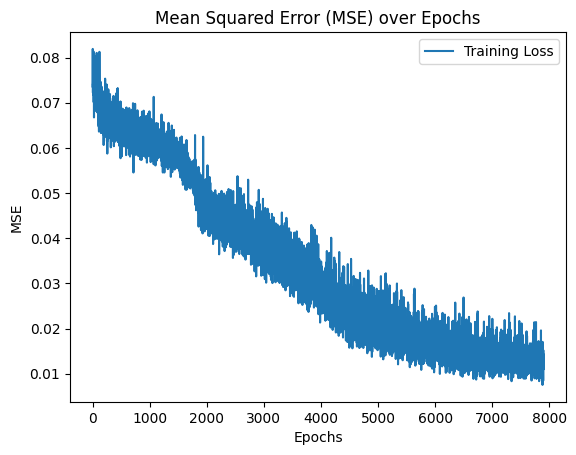

Low Fidelity NN
Test MSE: 0.038323834172903345
R^2: 0.6919592229060652


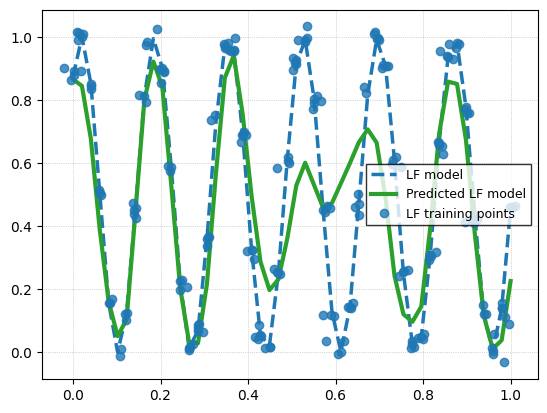

Second model
Test MSE: 0.0637643664195634
R^2: 0.4367045079525278


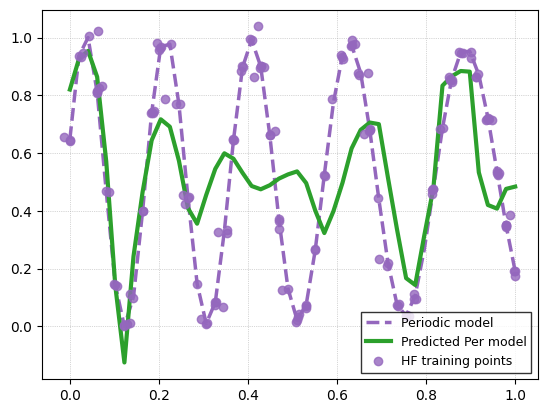

Third model
Test MSE: 0.022839157948164684
R^2: 0.7982384921743029


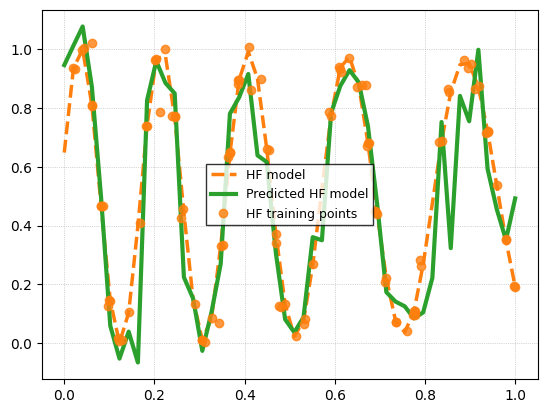

Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\3_step_models\10_model_0.keras
Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\3_step_models\10_model_1.keras
Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\3_step_models\10_model_2.keras
********************  # Nb. nodes = 10  ********************
********************  # Diff: = 75  ********************
********************  # NHF: = 100  ********************
********************  # Nper: = 150  ********************
********************  # NLF: = 200  ********************
The function training took 179.856727 seconds.


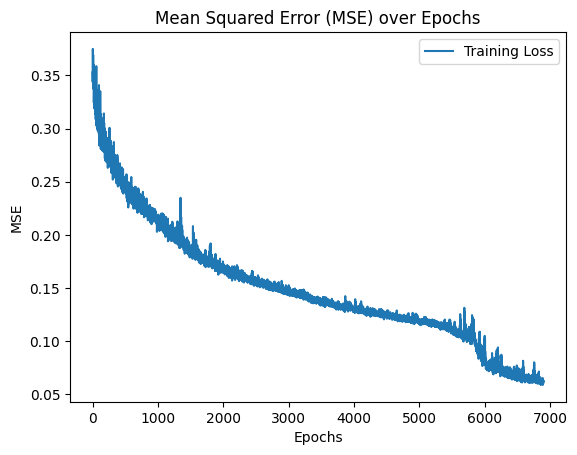

The function training took 39.604724 seconds.


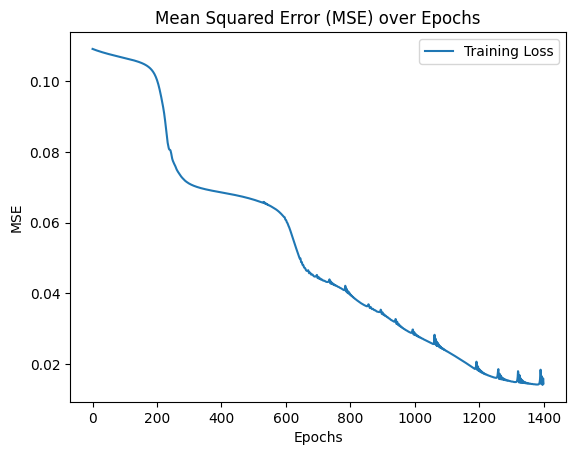

The function training took 192.670363 seconds.


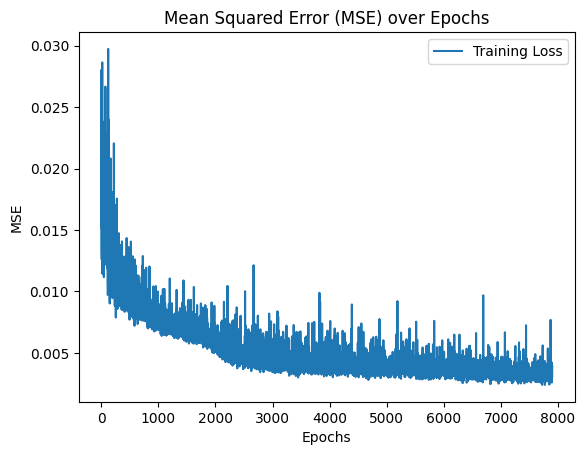

Low Fidelity NN
Test MSE: 0.003662246488725644
R^2: 0.9712931044474541


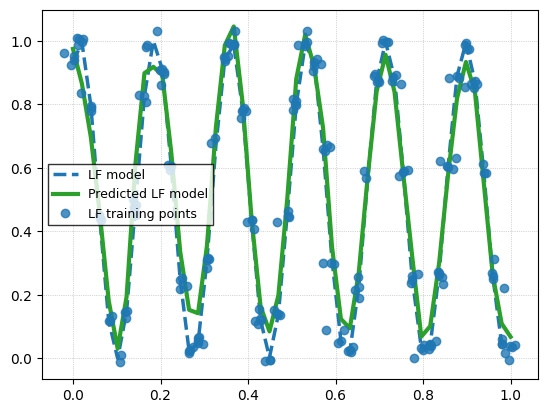

Second model
Test MSE: 0.006208631453568381
R^2: 0.9451528446692725


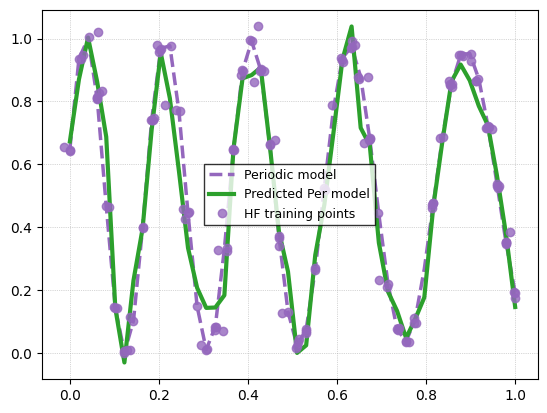

Third model
Test MSE: 0.002081015917808568
R^2: 0.981616270164633


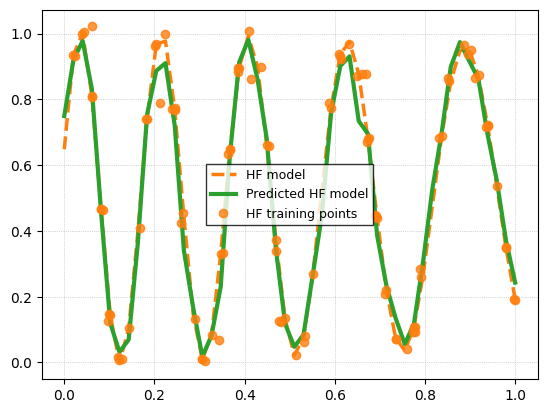

Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\3_step_models\10_model_0.keras
Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\3_step_models\10_model_1.keras
Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\3_step_models\10_model_2.keras
********************  # Nb. nodes = 10  ********************
********************  # Diff: = 1  ********************
********************  # NHF: = 100  ********************
********************  # Nper: = 150  ********************
********************  # NLF: = 200  ********************
The function training took 168.233142 seconds.


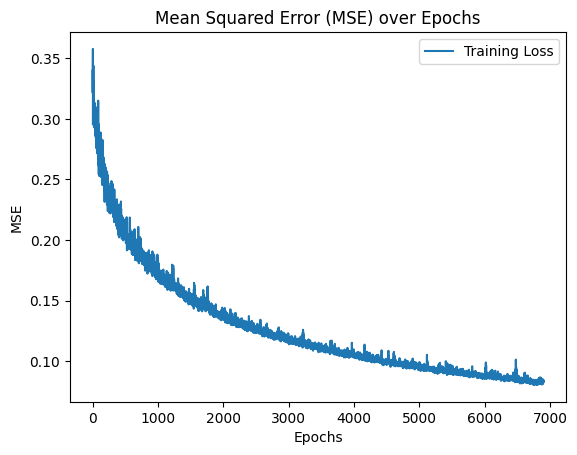

The function training took 36.614409 seconds.


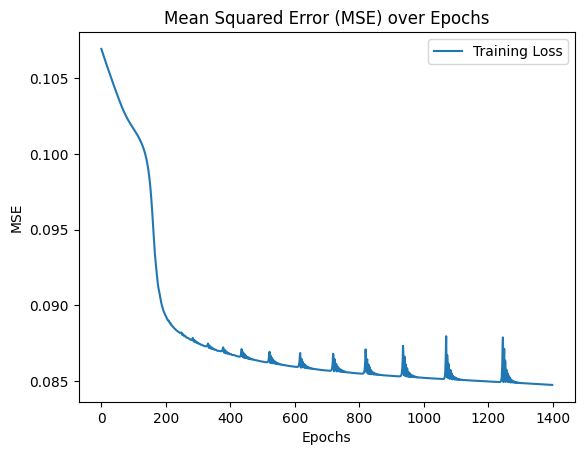

The function training took 193.988374 seconds.


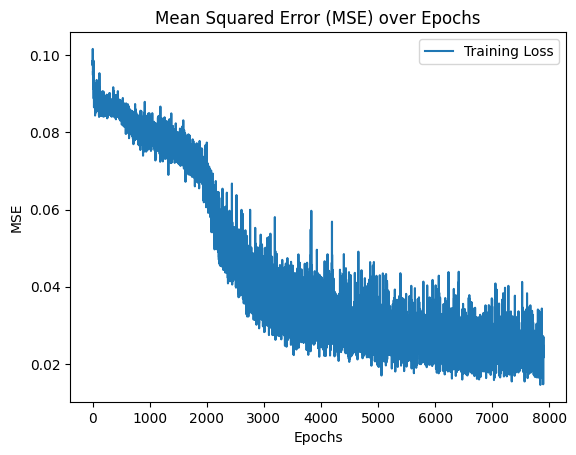

Low Fidelity NN
Test MSE: 0.03372273363723194
R^2: 0.7224315919761854


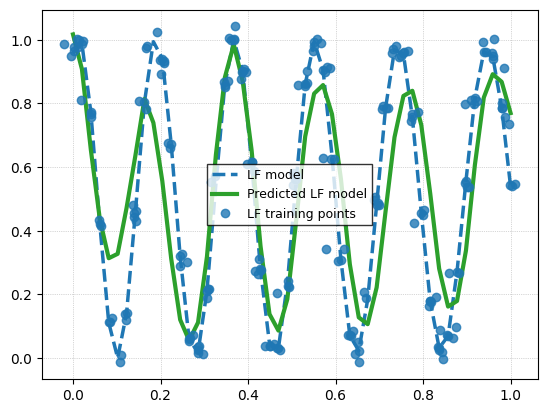

Second model
Test MSE: 0.0851525599398153
R^2: 0.24776084443797164


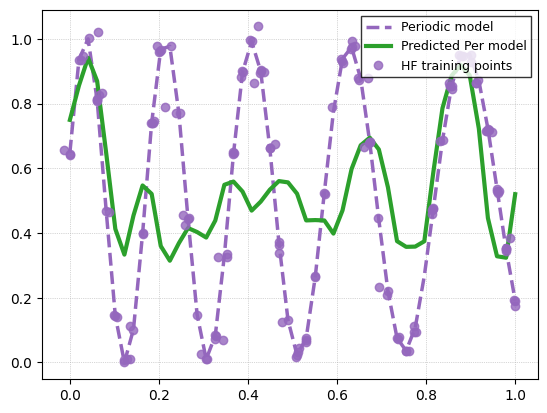

Third model
Test MSE: 0.03682997290760124
R^2: 0.6746433960532974


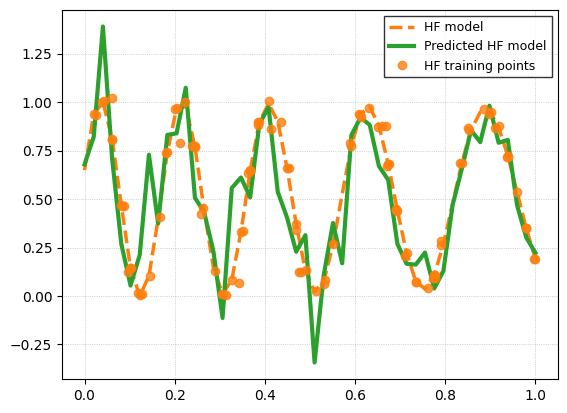

   Discretization Diffusion       R2  diffusion
0              46       NaN  0.83576        0.0
1              46       NaN  0.88929        5.0
2              46       NaN  0.94875       75.0
3              46       NaN  0.93353        1.0
4              28       NaN  0.69764        0.0
5              28       NaN  0.57205        5.0
6              28       NaN  0.93338       75.0
7              28       NaN  0.96851        1.0
8              10       NaN  0.58848        0.0
9              10       NaN  0.79824        5.0
10             10       NaN  0.98162       75.0
11             10       NaN  0.67464        1.0
   Discretization Diffusion      MSE  diffusion
0              46       NaN  0.01859        0.0
1              46       NaN  0.01253        5.0
2              46       NaN  0.00580       75.0
3              46       NaN  0.00752        1.0
4              28       NaN  0.03423        0.0
5              28       NaN  0.04844        5.0
6              28       NaN  0.00754    

In [10]:
# Define parameters
folder_name = "3_step_models"
folder_path = create_folder(folder_name)

# Iterate through discretizations, diffusion values, and model parameters
for m in range(len(Discretizations)):
    test_mse_HF_list = []
    test_mse_LF_list = []
    test_mse_per_list = []

    r2_HF_list = []
    r2_LF_list = []
    r2_per_list = []

    for d in range(len(diffusion)):
        for nhf in n_HF:
            for nlf in Nlf:
                for nper in n_per:

                    # Logging the current parameters
                    print(f"********************  # Nb. nodes = {Discretizations[m]}  ********************")
                    print(f"********************  # Diff: = {diffusion[d]}  ********************")
                    print(f"********************  # NHF: = {nhf}  ********************")
                    print(f"********************  # Nper: = {nper}  ********************")
                    print(f"********************  # NLF: = {nlf}  ********************")

                    # # Import and normalize the Low Fidelity (LF) dataset
                    # file_path_LF = f"../DATA_reaction_diffusion_test_case/reaction_diffusion_LF_{Discretizations[m]}_d{diffusion[d]}.mat"
                    # reaction_LF_test, U_LF_test = import_data(file_path_LF)
                    # U_LF_test = normalization(U_LF_test[:, -1, int(4*(Discretizations[m]-1)/9), int(4*(Discretizations[m]-1)/9)])
                    # reaction_LF_test = normalization(reaction_LF_test)

                    # # Preserve original LF test set
                    # reaction_LF_test_original = np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0] - 5*np.pi/6))]
                    # U_LF_test_original = U_LF_test.copy()

                    # # Augment LF dataset by adding noise
                    # noise_std1 = [0.02, 0.01, 0.02, 0.01]
                    # noise_std2 = [0.01, 0.005, 0.01, 0.005]
                    # U_LF_test, reaction_LF_test = add_noise(noise_std1, noise_std2, reaction_LF_test, U_LF_test.reshape(-1,1))

                    # # Shuffle and select the training sets
                    # reaction_LF, U_train_LF = shuffle_and_select(reaction_LF_test, U_LF_test, nlf)
                    # reaction_per, U_train_per = shuffle_and_select(reaction_HF_test, U_HF_test, nper)
                    # reaction_HF, U_HF = shuffle_and_select(reaction_HF_test, U_HF_test, nhf)

                    # # Transform LF dataset
                    # reaction_LF = np.c_[reaction_LF, np.abs(np.sin(5*np.pi*reaction_LF[:, 0] - 5*np.pi/6))]
                    # reaction_LF_test = np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0] - 5*np.pi/6))]


                    # Import Low Fidelity data
                    file_path_LF = f"../DATA_reaction_diffusion_test_case/reaction_diffusion_LF_{Discretizations[m]}_d{diffusion[d]}.mat"
                    reaction_LF_test, U_LF_test = import_data(file_path_LF)

                    # Normalize and select specific data points
                    U_LF_test = U_LF_test[:, -1, int(4*(Discretizations[m]-1)/9), int(4*(Discretizations[m]-1)/9)]
                    U_LF_test = normalization(U_LF_test)
                    reaction_LF_test = normalization(reaction_LF_test)
                    
                    # Transform Low Fidelity dataset
                    reaction_LF_test_original = np.c_[reaction_LF_test, np.abs(np.sin(5 * np.pi * reaction_LF_test[:, 0] - 5 * np.pi / 6))]
                    U_LF_test_original = U_LF_test  # Keep original for later use
                    
                    # Data augmentation with noise
                    noise_std1 = [0.02, 0.01, 0.02, 0.01]
                    noise_std2 = [0.01, 0.005, 0.01, 0.005]
                    U_LF_test, reaction_LF_test = add_noise(noise_std1, noise_std2, reaction_LF_test, U_LF_test.reshape(-1,1))
                    
                    # Prepare datasets for training and validation
                    reaction_LF, U_train_LF = select_random_data(reaction_LF_test, U_LF_test, nlf)
                    reaction_per, U_train_per = select_random_data(reaction_HF_test, U_HF_test, nper)
                    reaction_HF, U_HF = select_random_data(reaction_HF_test, U_HF_test, nhf)

                    # Transform datasets for training
                    reaction_LF = augment_with_sin(reaction_LF)
                    reaction_LF_test = augment_with_sin(reaction_LF_test)

                    # Prepare validation datasets
                    reaction_HF_val, U_HF_val = select_random_data(reaction_HF_test, U_HF_test, nhf)
                    reaction_per_val, U_per_val = select_random_data(reaction_HF_test, U_HF_test, nper)
                    reaction_LF_val, U_train_LF_val = select_random_data(reaction_LF_test, U_LF_test, nlf)

                    # Transform validation dataset
                    reaction_LF_val = augment_with_sin(reaction_LF_val)

                    ########################## Neural Network ##########################
                    K.clear_session()

                    bestLF_params = {'kernel_init': 'glorot_uniform',
                                    'l2weight': 0.055687407222784514,
                                    'lr': 0.013763036873234191,
                                    'nodes': 15,
                                    'opt': 'Adam'}
                    bestper_params = {'kernel_init': 'uniform',
                                        'l2weight': 0.00019723116196368882,
                                        'lr': 0.08155671235896393,
                                        'nodes': 7,
                                        'opt': 'Adamax'}
                    best_params = {'kernel_init': 'uniform',
                                    'l2weight': 0.00014981392074368653,
                                    'lr': 0.020280502294291045,
                                    'nodes': 14,
                                    'opt': 'Adamax'}

                    names = ["LF", "Hfper", "HF"]
                    params = [bestLF_params, bestper_params, best_params]
                    data_train = [reaction_LF, reaction_per, reaction_HF]
                    output_train = [U_train_LF, U_train_per, U_HF]

                    definition_3steps = {
                        "network_type": "3step",
                        "names": names,
                        "params": params,
                        "data_train": data_train,
                        "output_train": output_train,
                        "data_val": [reaction_LF_val, reaction_per_val, reaction_HF_val],
                        "output_val": [U_train_LF_val, U_per_val, U_HF_val],
                        "N": Nepo,
                        "n": batch_size,
                        "train": True,
                        "do_HPO": False,
                        "verbose": False
                    }
                    model = NetworkFactory.build_network(**definition_3steps)

                    ### Network 1 (Low Fidelity Model)
                    ULF = model.model_list[0].prediction(reaction_LF_test_original)
                    print("Low Fidelity NN")

                    test_mse_LF, r2_LF = model.model_list[0].performance(reaction_LF_test_original, U_LF_test_original)
                    test_mse_LF_list.append(test_mse_LF)
                    r2_LF_list.append(r2_LF)

                    plot_results(reaction_LF_test_original, U_LF_test_original, ULF, "LF",reaction_LF,  U_train_LF,"#1F77B4", "#2CA02C", "LF model", "Predicted LF model")

                    ### Network 2 (Intermediate Model)
                    input_per = np.concatenate((reaction_HF_test_original,  model.model_list[0].prediction(reaction_HF_test_original).reshape(-1,1)),axis=1 )
                    input_per_train = np.concatenate((reaction_HF,  model.model_list[0].prediction(reaction_HF).reshape(-1,1)),axis=1) 
                    print("Second model")
                    test_mse_per, r2_per = model.model_list[1].performance(input_per, U_HF_test_original)
                    test_mse_per_list.append(test_mse_per)
                    r2_per_list.append(r2_per)

                    plot_results(reaction_HF_test_original, U_HF_test_original, model.model_list[1].prediction(input_per),  "HF",  reaction_per,U_train_per, "#9467BD", "#2CA02C", "Periodic model", "Predicted Per model")

                    ### Network 3 (High Fidelity Model)
                    input_HF=np.concatenate((reaction_HF_test_original,  model.model_list[0].prediction(reaction_HF_test_original).reshape(-1,1)),axis=1) 

                    input_HF=np.concatenate((input_HF, model.model_list[1].prediction(input_HF).reshape(-1,1)),axis=1)


                    input_HF_train = np.concatenate((reaction_HF,  model.model_list[0].prediction(reaction_HF).reshape(-1,1)),axis=1) 

                    input_HF_train=np.concatenate((input_HF_train, model.model_list[1].prediction(input_HF_train).reshape(-1,1)),axis=1)

                    print("Third model")
                    test_mse_HF, r2_HF = model.performance(reaction_HF_test_original, U_HF_test_original)
                    test_mse_HF_list.append(test_mse_HF)
                    r2_HF_list.append(r2_HF)

                    plot_results(reaction_HF_test_original, U_HF_test_original, model.model_list[2].prediction(input_HF),"HF",reaction_HF,  U_HF, "#FF7F0E", "#2CA02C", "HF model", "Predicted HF model")

                    # Update DataFrames with results
                    r2_LF_df = update_results(r2_LF_df, Discretizations[m], diffusion[d], r2_LF_list[-1], "R2")
                    r2_HF_df = update_results(r2_HF_df, Discretizations[m], diffusion[d], r2_HF_list[-1], "R2")
                    mse_LF_df = update_results(mse_LF_df, Discretizations[m], diffusion[d], test_mse_LF_list[-1], "MSE")
                    mse_HF_df = update_results(mse_HF_df, Discretizations[m], diffusion[d], test_mse_HF_list[-1], "MSE")

                    # Save the model if it improves on the previous best R2 score
                    if not r2_HF_list[:-1] or (r2_HF_list[:-1] and r2_HF > max(r2_HF_list[:-1])):
                        # Create a list of file paths for each model in model_list
                        file_paths = [os.path.join(folder_path, f"{str(Discretizations[m])}_model_{i}.keras") for i in range(len(model.model_list))]
                        model.save(file_paths)


# Print the results
print(r2_HF_df.round(5))
print(mse_HF_df.round(5))

Folder '3_step_models' already exists.
********************  # Nb. nodes = 46  ********************
********************  # Diff: = 0  ********************
********************  # NHF: = 100  ********************
********************  # Nper: = 150  ********************
********************  # NLF: = 200  ********************
The function training took 137.797396 seconds.


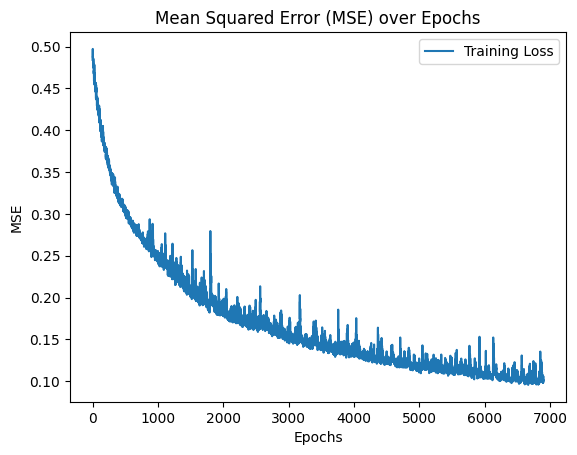

The function training took 29.372125 seconds.


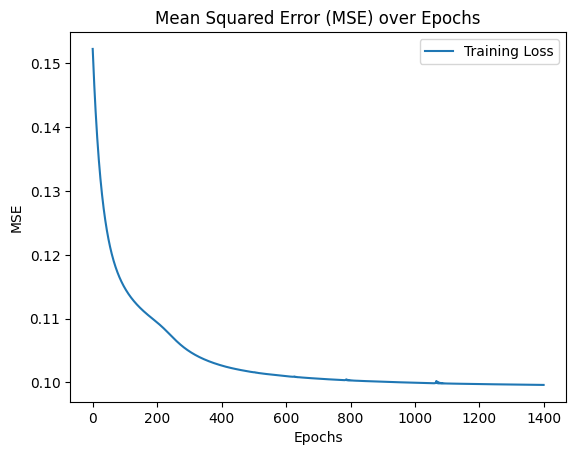

The function training took 148.017804 seconds.


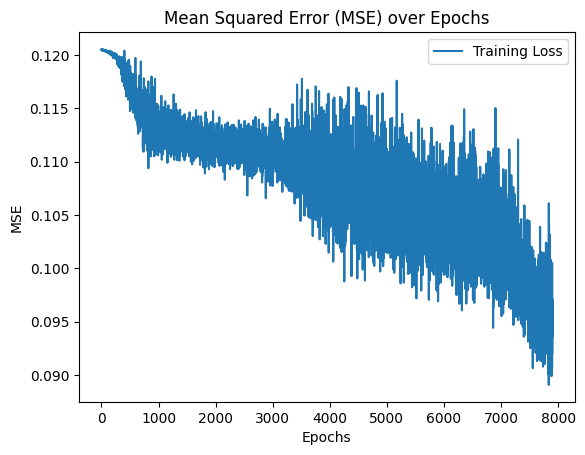

low fidelity NN
Test MSE: 0.01729800962633972
R^2: 0.8611518093358006


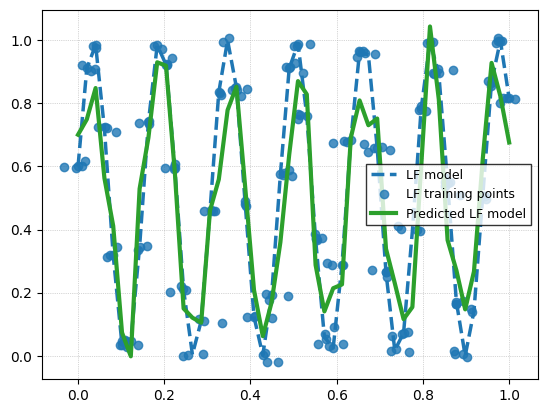

second model
Test MSE: 0.10449225348553912
R^2: 0.07691366436556901
Test MSE: 0.08121324096962805
R^2: 0.28256085488648397


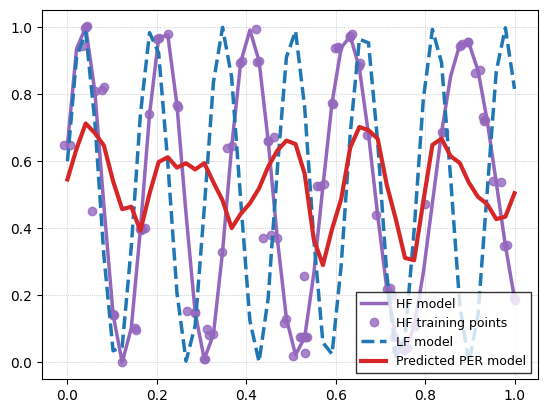

third model
Test MSE: 0.08121324096962805
R^2: 0.28256085488648397


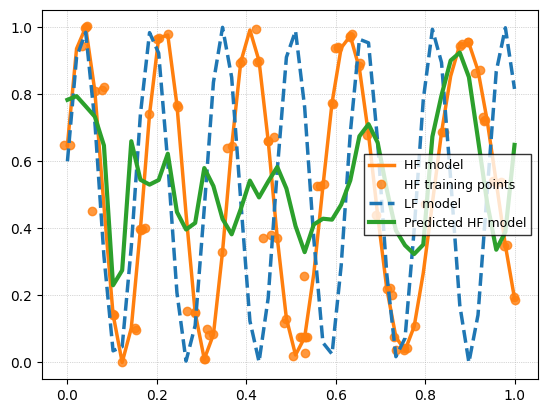

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_21664\3294530816.py:278: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  r2_LF_df = pd.concat([r2_LF_df, pd.DataFrame([new])], ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_21664\3294530816.py:281: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  r2_HF_df = pd.concat([r2_HF_df, pd.DataFrame([new])], ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_21664\3294530816.py:284: FutureWarning: The behavior of DataFrame concaten

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 5  ********************
********************  # NHF: = 100  ********************
********************  # Nper: = 150  ********************
********************  # NLF: = 200  ********************
The function training took 148.048589 seconds.


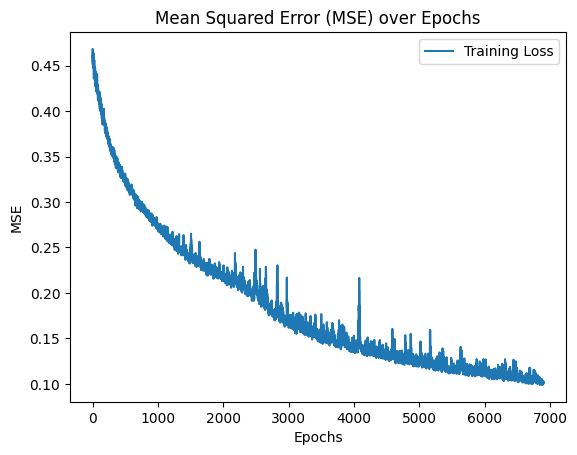

The function training took 29.259023 seconds.


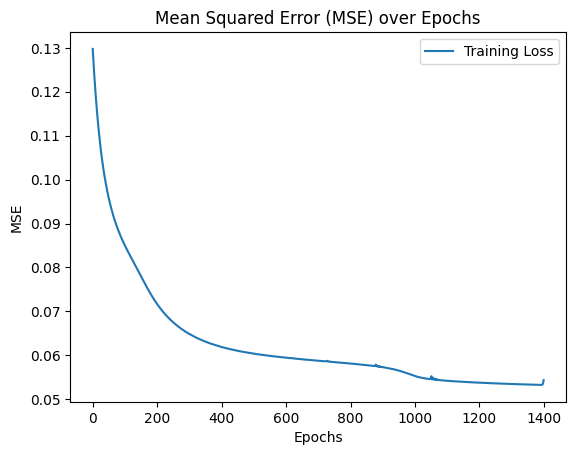

The function training took 151.999921 seconds.


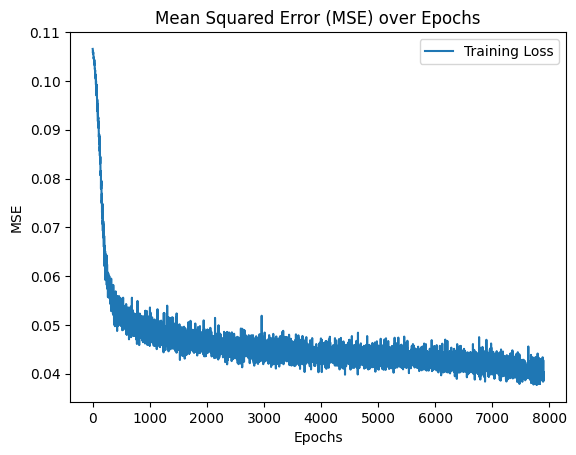

low fidelity NN
Test MSE: 0.01254792714609841
R^2: 0.889699822389579


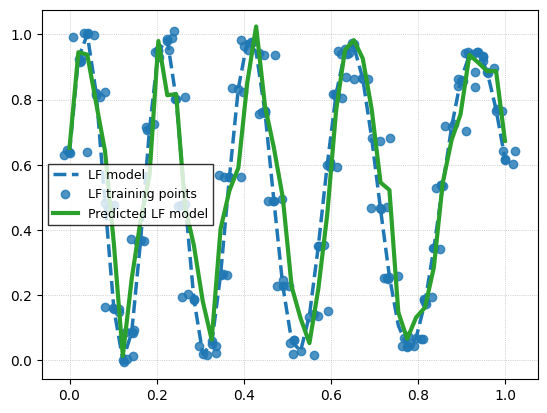

second model
Test MSE: 0.03946530560196311
R^2: 0.6513628224330457
Test MSE: 0.036608332102756935
R^2: 0.6766013746741635


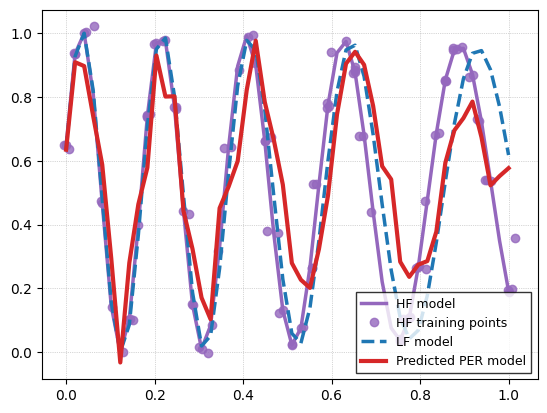

third model
Test MSE: 0.036608332102756935
R^2: 0.6766013746741635


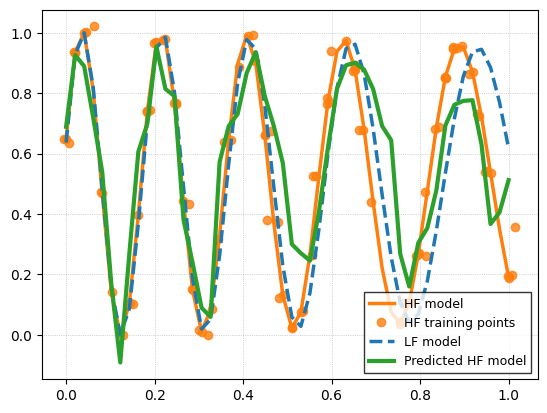

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 75  ********************
********************  # NHF: = 100  ********************
********************  # Nper: = 150  ********************
********************  # NLF: = 200  ********************
The function training took 141.095319 seconds.


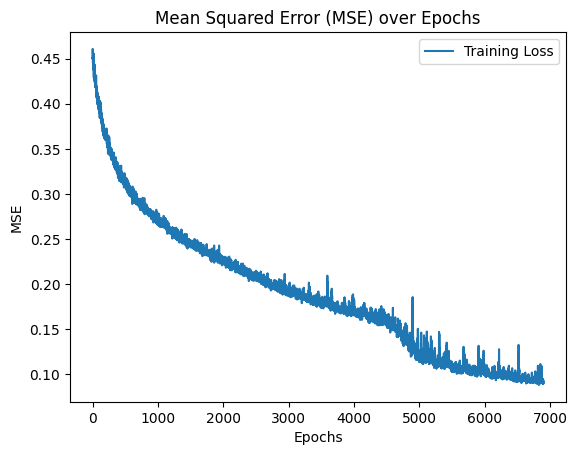

The function training took 29.869223 seconds.


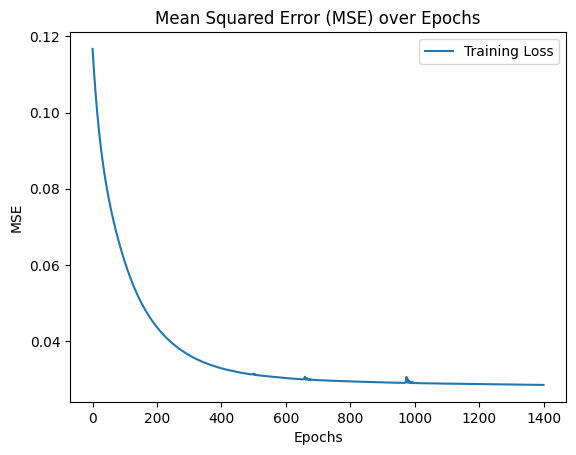

The function training took 152.132101 seconds.


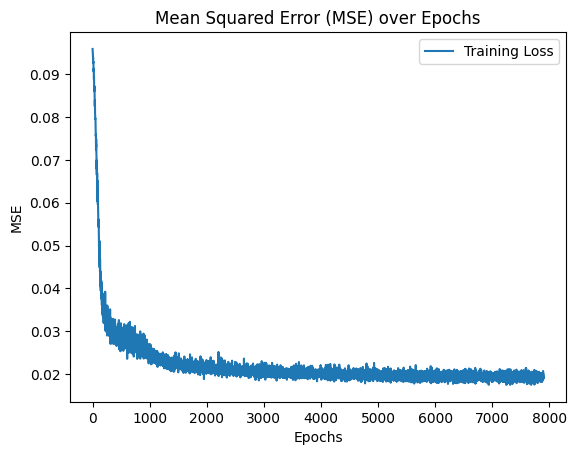

low fidelity NN
Test MSE: 0.00907281564630991
R^2: 0.9229734767971506


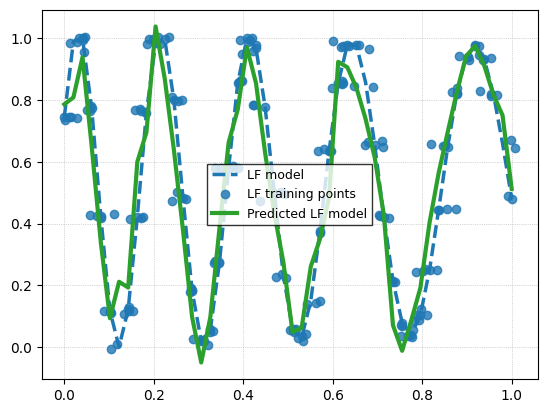

second model
Test MSE: 0.016793200106671645
R^2: 0.8516485860629989
Test MSE: 0.01476864513502627
R^2: 0.8695335389444603


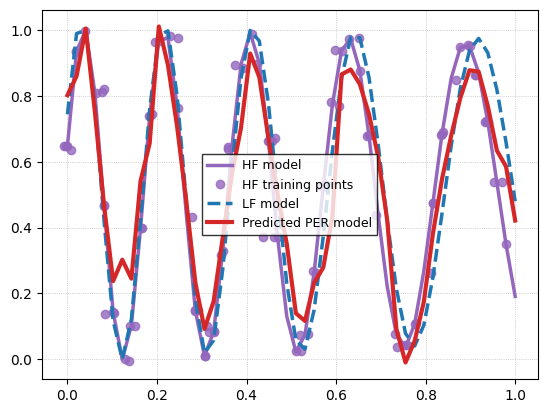

third model
Test MSE: 0.01476864513502627
R^2: 0.8695335389444603


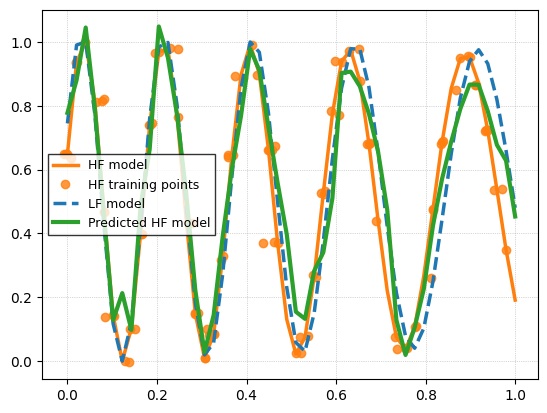

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 1  ********************
********************  # NHF: = 100  ********************
********************  # Nper: = 150  ********************
********************  # NLF: = 200  ********************


KeyboardInterrupt: 

In [ ]:
# Name of the folder
folder_name = "3_step_models"
folder_path = os.path.join(os.getcwd(), folder_name)

# create the folder
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Folder '{folder_name}' created.")
else:
    print(f"Folder '{folder_name}' already exists.")
               
for m in range(len(Discretizations)):
    test_mse_HF_list = []
    test_mse_LF_list = []
    test_mse_per_list = []

    r2_HF_list = []
    r2_LF_list = []
    r2_per_list = []

    for d in range(len(diffusion)):
        for nhf in n_HF:
            for nlf in Nlf:
                for nper in n_per:
        
                    print(
                    f"********************  # Nb. nodes = {Discretizations[m]}  ********************"
                    )
                    
                    print(
                    f"********************  # Diff: = {diffusion[d]}  ********************"
                    )
                    
                    print(
                    f"********************  # NHF: = {nhf}  ********************"
                    )
                    print(
                    f"********************  # Nper: = {nper}  ********************"
                    )

                    print(
                    f"********************  # NLF: = {nlf}  ********************"
                    )

                    
                    ### import of the Low Fidelity component of the dataset 
                    file_path_LF = "../DATA_reaction/reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat"
                    (reaction_LF_test, U_LF_test) = import_data(file_path_LF)

                    # selection and normalization of the dataset
                    U_LF_test = U_LF_test[:,- 1,int(4*(Discretizations[m]-1)/9),int(4*(Discretizations[m]-1)/9)] # indexes to find the same temporal (last) and spatial points        
                    U_LF_test = normalization(U_LF_test)
                    reaction_LF_test = normalization(reaction_LF_test)
                    
                    # transformation of the Low fidelity test set
                    reaction_LF_test_original=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
                    U_LF_test_original=U_LF_test # keep the original for later evaluation and representation 
                    
                    # dataset augmentation adding a noise
                    noise_std1=[0.02,0.01,0.02,0.01]
                    noise_std2=[0.01,0.005,0.01,0.005]
                    (U_LF_test,reaction_LF_test)=add_noise(noise_std1,noise_std2,reaction_LF_test,U_LF_test)
                    
                    # randomization and selection of the training set

                    permutation = np.random.permutation(len(reaction_LF_test))
                    reaction_LF = reaction_LF_test[permutation][0:nlf]
                    U_train_LF = U_LF_test[permutation][0:nlf]

                    permutation = np.random.permutation(len(reaction_HF_test))
                    reaction_per = reaction_HF_test[permutation,:][0:nper,:]
                    U_train_per = U_HF_test[permutation][0:nper]

                    permutation = np.random.permutation(len(reaction_HF_test))
                    reaction_HF = reaction_HF_test[permutation,:][0:nhf,:]
                    U_HF = U_HF_test[permutation][0:nhf]


                    # transformation of the dataset
                    reaction_LF=np.c_[reaction_LF, np.abs(np.sin(5*np.pi*reaction_LF[:, 0]-5*np.pi/6))]
                    reaction_LF_test=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
                    
                    ##########################      Neural Network     ##########################
                    K.clear_session()
                    
                    # parameters 
                    bestLF_params = {
                        "lr": 0.0255,
                        "kernel_init": "glorot_uniform",
                        "opt": "Adam",
                    } 
                    bestper_params = {
                        "lr": 0.002,
                        "kernel_init": "glorot_uniform",
                        "opt": "Adam",
                        "l2weight": 0.01,
                    }
                    best_params={'kernel_init': 'uniform', 
                                'l2weight': 0.005395541657336886, 
                                'lr': 0.0025412188591473228, 
                                'nodes': 12.0, 
                                'opt': 'Adamax'}


                    # Multifidelity network 
                    names=["LF","Hfper","HF"]
                    params=[bestLF_params, bestper_params, best_params]
                    data_train=[reaction_LF, reaction_per,reaction_HF]
                    output_train=[U_train_LF, U_train_per, U_HF]

                    definition_3steps = {
                                        "network_type": "2step",
                                        "names": names,
                                        "params": params,
                                        "data_train": data_train,
                                        "output_train": output_train,
                                        "N": Nepo,
                                        "n": batch_size,
                                        "train": True,
                                        "do_HPO": False,
                                        "verbose": False
                                        }
                    model= NetworkFactory.build_network(**definition_3steps)
    

    ### Network 1
                    ULF = model.model_list[0].prediction(reaction_LF_test_original)
                    print("low fidelity NN")
                    
                    (test_mse_LF,r2_LF) = model.model_list[0].performance(reaction_LF_test_original,U_LF_test_original)
                    test_mse_LF_list.append(test_mse_LF)
                    r2_LF_list.append(r2_LF)

    ### Plot Network 1

                    plt.figure()

                    plt.plot(reaction_LF_test_original[:, 0], U_LF_test_original, color="#1F77B4", linestyle="--", linewidth=2.5, label="LF model")

                    plt.plot(
                        reaction_LF[:, 0],
                        U_train_LF,
                        "o",
                        markersize=6,
                        color="#1F77B4",
                        alpha=0.8,
                        label="LF training points",
                    )

                    plt.plot(
                        reaction_LF_test_original[:, 0],
                        model.model_list[0].prediction(reaction_LF_test_original),
                        color="#2CA02C",
                        linestyle="-",
                        linewidth=3,
                        label="Predicted LF model",
                    )

                    plt.legend(prop={"size": 9}, loc="best", frameon=True, fancybox=False, shadow=False, facecolor="white", edgecolor="black")
                    plt.grid(True, which='both', linestyle=':', linewidth=0.5)

                    plt.show()

    ### Network 2

                    input_per = np.concatenate(
                        (reaction_HF_test_original,  model.model_list[0].prediction(reaction_HF_test_original).reshape(-1,1)),axis=1
                    )  # <- TRAINING INPUT for the second NN: NN_HF

                    input_per_train = np.concatenate(
                        (reaction_HF,  model.model_list[0].prediction(reaction_HF).reshape(-1,1)),axis=1
                    ) 

                    print("second model")
                    (test_mse_per,r2_per) = model.model_list[1].performance(input_per,U_HF_test_original)
                    test_mse_per_list.append(test_mse_per)
                    r2_per_list.append(r2_per)


                    (test_mse_per,r2_per) = model.performance(reaction_HF_test_original,U_HF_test_original)                
                    test_mse_per_list.append(test_mse_per)
                    r2_per_list.append(r2_per)
                    
    ### Plot Network 2


                    plt.figure()

                    plt.plot(reaction_HF_test_original[:,0], U_HF_test_original, color="#9467BD", linestyle="-", linewidth=2.5, label="HF model")

                    plt.plot(
                        input_per_train[:, 0],
                        U_HF,
                        "o",
                        markersize=6,
                        color="#9467BD",
                        alpha=0.8,
                        label="HF training points",
                    )

                    plt.plot(reaction_LF_test_original[:, 0], U_LF_test_original, color="#1F77B4", linestyle="--", linewidth=2.5, label="LF model")

                    plt.plot(
                        input_per[:, 0],
                        model.model_list[1].prediction(input_per),
                        color="#D62728",
                        linestyle="-",
                        linewidth=3,
                        label="Predicted PER model",
                    )

                    plt.legend(prop={"size": 9}, loc="best", frameon=True, fancybox=False, shadow=False, facecolor="white", edgecolor="black")
                    plt.grid(True, which='both', linestyle=':', linewidth=0.5)

                    plt.show()



                    # plots of the model
    ### Network 3
                    input_HF=np.concatenate(
                        (reaction_HF_test_original,  model.model_list[0].prediction(reaction_HF_test_original).reshape(-1,1)),axis=1
                    ) 

                    input_HF=np.concatenate((input_HF, model.model_list[1].prediction(input_HF).reshape(-1,1)),axis=1)


                    input_HF_train = np.concatenate(
                        (reaction_HF,  model.model_list[0].prediction(reaction_HF).reshape(-1,1)),axis=1
                    ) 

                    input_HF_train=np.concatenate((input_HF_train, model.model_list[1].prediction(input_HF_train).reshape(-1,1)),axis=1)


                    print("third model")
                    (test_mse_HF,r2_HF) = model.performance(reaction_HF_test_original,U_HF_test_original)                
                    test_mse_HF_list.append(test_mse_HF)
                    r2_HF_list.append(r2_HF)
                    
    ### Plot Network 3


                    plt.figure()

                    plt.plot(reaction_HF_test_original[:,0], U_HF_test_original, color="#FF7F0E", linestyle="-", linewidth=2.5, label="HF model")

                    plt.plot(
                        input_HF_train[:, 0],
                        U_HF,
                        "o",
                        markersize=6,
                        color="#FF7F0E",
                        alpha=0.8,
                        label="HF training points",
                    )

                    plt.plot(reaction_LF_test_original[:, 0], U_LF_test_original, color="#1F77B4", linestyle="--", linewidth=2.5, label="LF model")

                    plt.plot(
                        input_HF[:, 0],
                        model.model_list[2].prediction(input_HF),
                        color="#2CA02C",
                        linestyle="-",
                        linewidth=3,
                        label="Predicted HF model",
                    )

                    plt.legend(prop={"size": 9}, loc="best", frameon=True, fancybox=False, shadow=False, facecolor="white", edgecolor="black")
                    plt.grid(True, which='both', linestyle=':', linewidth=0.5)

                    plt.show()


                    

                    
                    new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_LF_list[-1]}
                    r2_LF_df = pd.concat([r2_LF_df, pd.DataFrame([new])], ignore_index=True)

                    new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_HF_list[-1]}
                    r2_HF_df = pd.concat([r2_HF_df, pd.DataFrame([new])], ignore_index=True)

                    new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_LF_list[-1]}
                    mse_LF_df = pd.concat([mse_LF_df, pd.DataFrame([new])], ignore_index=True)

                    new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_HF_list[-1]}
                    mse_HF_df = pd.concat([mse_HF_df, pd.DataFrame([new])], ignore_index=True)
                
                
                    # # save the model
                    # if not r2_HF_list[:-1]:
                    #     model.save(str(Discretizations[m]),folder_path)
                    # elif r2_HF_list[:-1] and r2_HF_list[-1] < max(r2_HF_list[:-1]):
                    #     model.save(str(Discretizations[m]),folder_path)

        
print(r2_HF_df.round(5))
print(mse_HF_df.round(5))

Folder '3_step_models' already exists.
********************  # Nb. nodes = 46  ********************
********************  # Diff: = 75  ********************
********************  # NHF: = 100  ********************
********************  # Nper: = 150  ********************
********************  # NLF: = 200  ********************


[I 2024-08-15 12:42:15,057] A new study created in memory with name: no-name-e3c6618f-9858-4722-ab61-fbb4462dc847
[I 2024-08-15 12:44:44,382] Trial 0 finished with value: 0.07492202030171333 and parameters: {'nodes': 13, 'l2weight': 0.006560890044989014, 'lr': 0.00763517658469449, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 0 with value: 0.07492202030171333.
[I 2024-08-15 12:47:17,787] Trial 1 finished with value: 0.12868067264455618 and parameters: {'nodes': 7, 'l2weight': 0.0006842389824501549, 'lr': 0.0034630412753161224, 'kernel_init': 'glorot_uniform', 'opt': 'Adam'}. Best is trial 0 with value: 0.07492202030171333.
[I 2024-08-15 12:49:55,710] Trial 2 finished with value: 0.05674653811240941 and parameters: {'nodes': 4, 'l2weight': 0.0008908698066317102, 'lr': 0.022419103896217894, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 2 with value: 0.05674653811240941.
[I 2024-08-15 12:52:33,719] Trial 3 finished with value: 0.11276433370595874 and 

The function training took 139.987949 seconds.


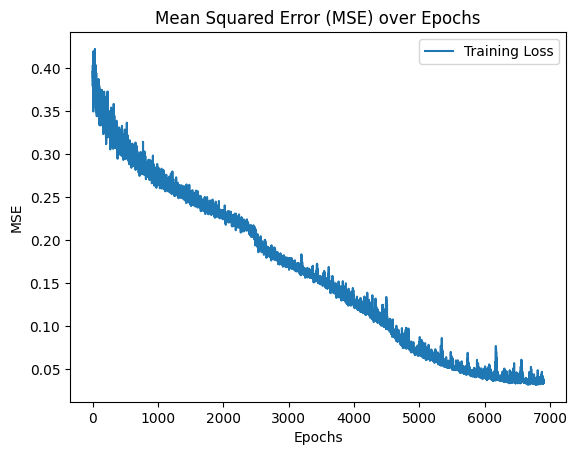

[I 2024-08-15 12:57:33,564] A new study created in memory with name: no-name-d0d390ee-fe4b-4606-9d90-8b63d4cd03f4
[I 2024-08-15 12:58:12,867] Trial 0 finished with value: 0.02460856215963498 and parameters: {'nodes': 9, 'l2weight': 0.005484729091178437, 'lr': 0.052963487324388055, 'kernel_init': 'glorot_uniform', 'opt': 'Adam'}. Best is trial 0 with value: 0.02460856215963498.
[I 2024-08-15 12:58:46,466] Trial 1 finished with value: 0.023631915222714364 and parameters: {'nodes': 28, 'l2weight': 0.008200164846709365, 'lr': 0.05153376649206307, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 1 with value: 0.023631915222714364.
[I 2024-08-15 12:59:23,759] Trial 2 finished with value: 0.11368976968282693 and parameters: {'nodes': 22, 'l2weight': 0.08554540714654389, 'lr': 0.03125883763129905, 'kernel_init': 'glorot_uniform', 'opt': 'Adam'}. Best is trial 1 with value: 0.023631915222714364.
[I 2024-08-15 13:00:00,560] Trial 3 finished with value: 0.019431322087939407 and pa

The function training took 28.967681 seconds.


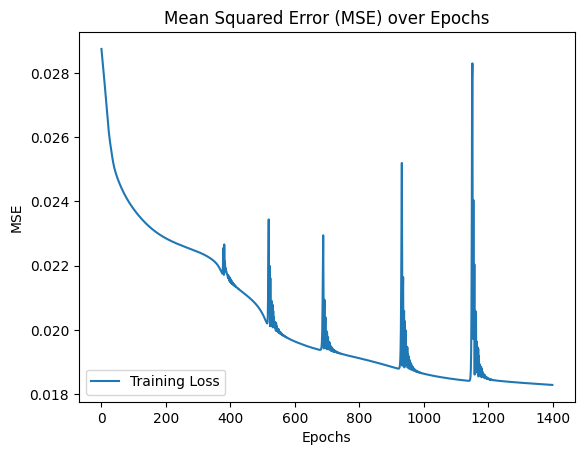

[I 2024-08-15 13:01:07,777] A new study created in memory with name: no-name-2e53872c-eba6-4845-ba0f-a5448339554b
[I 2024-08-15 13:04:07,336] Trial 0 finished with value: 0.02246839919320241 and parameters: {'nodes': 12, 'l2weight': 0.008932622739761708, 'lr': 0.006478739574646008, 'kernel_init': 'glorot_uniform', 'opt': 'Adam'}. Best is trial 0 with value: 0.02246839919320241.
[I 2024-08-15 13:07:00,859] Trial 1 finished with value: 0.02322323288076587 and parameters: {'nodes': 18, 'l2weight': 0.0011998605677092965, 'lr': 0.00011676585085643735, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 0 with value: 0.02246839919320241.
[I 2024-08-15 13:09:54,324] Trial 2 finished with value: 0.02295075644675188 and parameters: {'nodes': 4, 'l2weight': 0.012995075978536975, 'lr': 0.0003642558939553106, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 0 with value: 0.02246839919320241.
[I 2024-08-15 13:12:59,169] Trial 3 finished with value: 0.022313575088144896 

The function training took 154.031057 seconds.


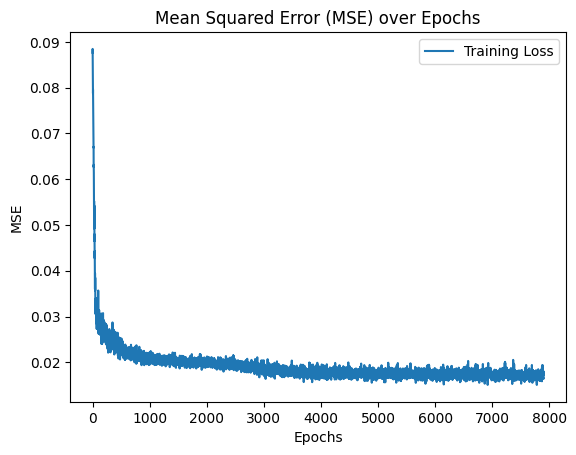

low fidelity NN
Test MSE: 0.005420262621543076
R^2: 0.9539829749815723


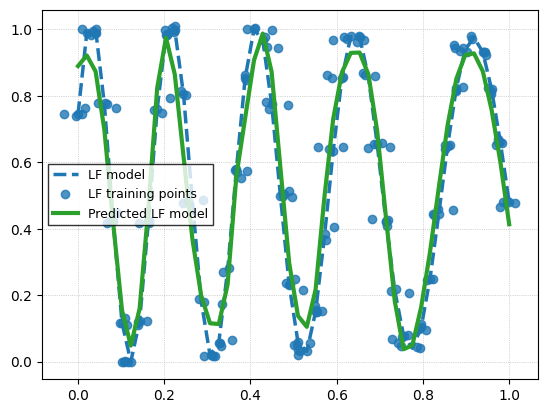

second model
Test MSE: 0.008638632325388862
R^2: 0.9236861758442226
Test MSE: 0.007995016922292389
R^2: 0.9293718852072083


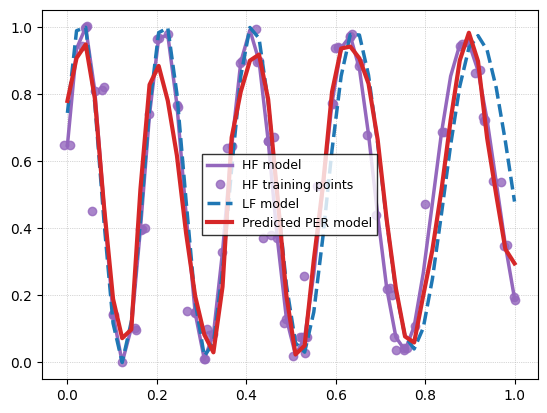

third model
Test MSE: 0.007995016922292389
R^2: 0.9293718852072083


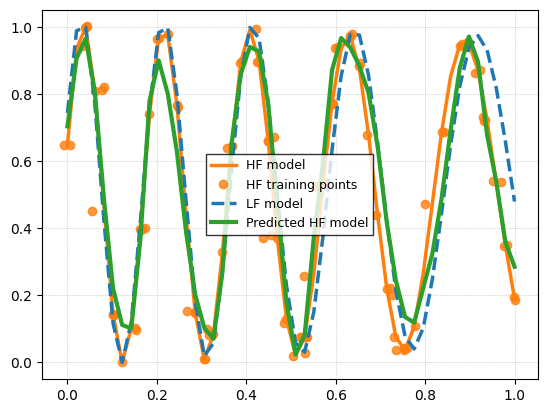

  Discretization Diffusion       R2  diffusion
0             46       NaN  0.92937       75.0
  Discretization Diffusion    MSE  diffusion
0             46       NaN  0.008       75.0


C:\Users\Giacomo\AppData\Local\Temp\ipykernel_1368\1222044636.py:278: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  r2_LF_df = pd.concat([r2_LF_df, pd.DataFrame([new])], ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_1368\1222044636.py:281: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  r2_HF_df = pd.concat([r2_HF_df, pd.DataFrame([new])], ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_1368\1222044636.py:284: FutureWarning: The behavior of DataFrame concatenati

In [16]:
# Name of the folder
folder_name = "3_step_models"
folder_path = os.path.join(os.getcwd(), folder_name)

# create the folder
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Folder '{folder_name}' created.")
else:
    print(f"Folder '{folder_name}' already exists.")
               
for m in range(len(Discretizations)):
    test_mse_HF_list = []
    test_mse_LF_list = []
    test_mse_per_list = []

    r2_HF_list = []
    r2_LF_list = []
    r2_per_list = []

    for d in range(len(diffusion)):
        for nhf in n_HF:
            for nlf in Nlf:
                for nper in n_per:
        
                    print(
                    f"********************  # Nb. nodes = {Discretizations[m]}  ********************"
                    )
                    
                    print(
                    f"********************  # Diff: = {diffusion[d]}  ********************"
                    )
                    
                    print(
                    f"********************  # NHF: = {nhf}  ********************"
                    )
                    print(
                    f"********************  # Nper: = {nper}  ********************"
                    )

                    print(
                    f"********************  # NLF: = {nlf}  ********************"
                    )

                    
                    ### import of the Low Fidelity component of the dataset 
                    file_path_LF = "../DATA_reaction/reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat"
                    (reaction_LF_test, U_LF_test) = import_data(file_path_LF)

                    # selection and normalization of the dataset
                    U_LF_test = U_LF_test[:,- 1,int(4*(Discretizations[m]-1)/9),int(4*(Discretizations[m]-1)/9)] # indexes to find the same temporal (last) and spatial points        
                    U_LF_test = normalization(U_LF_test)
                    reaction_LF_test = normalization(reaction_LF_test)
                    
                    # transformation of the Low fidelity test set
                    reaction_LF_test_original=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
                    U_LF_test_original=U_LF_test # keep the original for later evaluation and representation 
                    
                    # dataset augmentation adding a noise
                    noise_std1=[0.02,0.01,0.02,0.01]
                    noise_std2=[0.01,0.005,0.01,0.005]
                    (U_LF_test,reaction_LF_test)=add_noise(noise_std1,noise_std2,reaction_LF_test,U_LF_test)
                    
                    # randomization and selection of the training set

                    permutation = np.random.permutation(len(reaction_LF_test))
                    reaction_LF = reaction_LF_test[permutation][0:nlf]
                    U_train_LF = U_LF_test[permutation][0:nlf]

                    permutation = np.random.permutation(len(reaction_HF_test))
                    reaction_per = reaction_HF_test[permutation,:][0:nper,:]
                    U_train_per = U_HF_test[permutation][0:nper]

                    permutation = np.random.permutation(len(reaction_HF_test))
                    reaction_HF = reaction_HF_test[permutation,:][0:nhf,:]
                    U_HF = U_HF_test[permutation][0:nhf]


                    # transformation of the dataset
                    reaction_LF=np.c_[reaction_LF, np.abs(np.sin(5*np.pi*reaction_LF[:, 0]-5*np.pi/6))]
                    reaction_LF_test=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
                    
                    ##########################      Neural Network     ##########################
                    K.clear_session()
                    
                    # parameters 
                    bestLF_params = {
                        "lr": 0.0255,
                        "kernel_init": "glorot_uniform",
                        "opt": "Adam",
                    } 
                    bestper_params = {
                        "lr": 0.002,
                        "kernel_init": "glorot_uniform",
                        "opt": "Adam",
                        "l2weight": 0.01,
                    }
                    best_params={'kernel_init': 'uniform', 
                                'l2weight': 0.005395541657336886, 
                                'lr': 0.0025412188591473228, 
                                'nodes': 12.0, 
                                'opt': 'Adamax'}


                    # Multifidelity network 
                    names=["LF","Hfper","HF"]
                    params=[bestLF_params, bestper_params, best_params]
                    data_train=[reaction_LF, reaction_per,reaction_HF]
                    output_train=[U_train_LF, U_train_per, U_HF]

                    definition_3steps = {
                                        "network_type": "2step",
                                        "names": names,
                                        "params": params,
                                        "data_train": data_train,
                                        "output_train": output_train,
                                        "N": Nepo,
                                        "n": batch_size,
                                        "train": True,
                                        "do_HPO": True,
                                        "verbose": False
                                        }
                    model= NetworkFactory.build_network(**definition_3steps)
    

    ### Network 1
                    ULF = model.model_list[0].prediction(reaction_LF_test_original)
                    print("low fidelity NN")
                    
                    (test_mse_LF,r2_LF) = model.model_list[0].performance(reaction_LF_test_original,U_LF_test_original)
                    test_mse_LF_list.append(test_mse_LF)
                    r2_LF_list.append(r2_LF)

    ### Plot Network 1

                    plt.figure()

                    plt.plot(reaction_LF_test_original[:, 0], U_LF_test_original, color="#1F77B4", linestyle="--", linewidth=2.5, label="LF model")

                    plt.plot(
                        reaction_LF[:, 0],
                        U_train_LF,
                        "o",
                        markersize=6,
                        color="#1F77B4",
                        alpha=0.8,
                        label="LF training points",
                    )

                    plt.plot(
                        reaction_LF_test_original[:, 0],
                        model.model_list[0].prediction(reaction_LF_test_original),
                        color="#2CA02C",
                        linestyle="-",
                        linewidth=3,
                        label="Predicted LF model",
                    )

                    plt.legend(prop={"size": 9}, loc="best", frameon=True, fancybox=False, shadow=False, facecolor="white", edgecolor="black")
                    plt.grid(True, which='both', linestyle=':', linewidth=0.5)

                    plt.show()

    ### Network 2

                    input_per = np.concatenate(
                        (reaction_HF_test_original,  model.model_list[0].prediction(reaction_HF_test_original).reshape(-1,1)),axis=1
                    )  # <- TRAINING INPUT for the second NN: NN_HF

                    input_per_train = np.concatenate(
                        (reaction_HF,  model.model_list[0].prediction(reaction_HF).reshape(-1,1)),axis=1
                    ) 

                    print("second model")
                    (test_mse_per,r2_per) = model.model_list[1].performance(input_per,U_HF_test_original)
                    test_mse_per_list.append(test_mse_per)
                    r2_per_list.append(r2_per)


                    (test_mse_per,r2_per) = model.performance(reaction_HF_test_original,U_HF_test_original)                
                    test_mse_per_list.append(test_mse_per)
                    r2_per_list.append(r2_per)
                    
    ### Plot Network 2


                    plt.figure()

                    plt.plot(reaction_HF_test_original[:,0], U_HF_test_original, color="#9467BD", linestyle="-", linewidth=2.5, label="HF model")

                    plt.plot(
                        input_per_train[:, 0],
                        U_HF,
                        "o",
                        markersize=6,
                        color="#9467BD",
                        alpha=0.8,
                        label="HF training points",
                    )

                    plt.plot(reaction_LF_test_original[:, 0], U_LF_test_original, color="#1F77B4", linestyle="--", linewidth=2.5, label="LF model")

                    plt.plot(
                        input_per[:, 0],
                        model.model_list[1].prediction(input_per),
                        color="#D62728",
                        linestyle="-",
                        linewidth=3,
                        label="Predicted PER model",
                    )

                    plt.legend(prop={"size": 9}, loc="best", frameon=True, fancybox=False, shadow=False, facecolor="white", edgecolor="black")
                    plt.grid(True, which='both', linestyle=':', linewidth=0.5)

                    plt.show()



                    # plots of the model
    ### Network 3
                    input_HF=np.concatenate(
                        (reaction_HF_test_original,  model.model_list[0].prediction(reaction_HF_test_original).reshape(-1,1)),axis=1
                    ) 

                    input_HF=np.concatenate((input_HF, model.model_list[1].prediction(input_HF).reshape(-1,1)),axis=1)


                    input_HF_train = np.concatenate(
                        (reaction_HF,  model.model_list[0].prediction(reaction_HF).reshape(-1,1)),axis=1
                    ) 

                    input_HF_train=np.concatenate((input_HF_train, model.model_list[1].prediction(input_HF_train).reshape(-1,1)),axis=1)


                    print("third model")
                    (test_mse_HF,r2_HF) = model.performance(reaction_HF_test_original,U_HF_test_original)                
                    test_mse_HF_list.append(test_mse_HF)
                    r2_HF_list.append(r2_HF)
                    
    ### Plot Network 3


                    plt.figure()

                    plt.plot(reaction_HF_test_original[:,0], U_HF_test_original, color="#FF7F0E", linestyle="-", linewidth=2.5, label="HF model")

                    plt.plot(
                        input_HF_train[:, 0],
                        U_HF,
                        "o",
                        markersize=6,
                        color="#FF7F0E",
                        alpha=0.8,
                        label="HF training points",
                    )

                    plt.plot(reaction_LF_test_original[:, 0], U_LF_test_original, color="#1F77B4", linestyle="--", linewidth=2.5, label="LF model")

                    plt.plot(
                        input_HF[:, 0],
                        model.model_list[2].prediction(input_HF),
                        color="#2CA02C",
                        linestyle="-",
                        linewidth=3,
                        label="Predicted HF model",
                    )

                    plt.legend(prop={"size": 9}, loc="best", frameon=True, fancybox=False, shadow=False, facecolor="white", edgecolor="black")
                    plt.grid(True, which='both', linestyle=':', linewidth=0.5)

                    plt.show()


                    

                    
                    new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_LF_list[-1]}
                    r2_LF_df = pd.concat([r2_LF_df, pd.DataFrame([new])], ignore_index=True)

                    new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_HF_list[-1]}
                    r2_HF_df = pd.concat([r2_HF_df, pd.DataFrame([new])], ignore_index=True)

                    new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_LF_list[-1]}
                    mse_LF_df = pd.concat([mse_LF_df, pd.DataFrame([new])], ignore_index=True)

                    new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_HF_list[-1]}
                    mse_HF_df = pd.concat([mse_HF_df, pd.DataFrame([new])], ignore_index=True)
                
                
                    # # save the model
                    # if not r2_HF_list[:-1]:
                    #     model.save(str(Discretizations[m]),folder_path)
                    # elif r2_HF_list[:-1] and r2_HF_list[-1] < max(r2_HF_list[:-1]):
                    #     model.save(str(Discretizations[m]),folder_path)

        
print(r2_HF_df.round(5))
print(mse_HF_df.round(5))

## Save the output

In [ ]:
base_directory = "MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class"
save_dataframes_and_lists(
    base_dir=base_directory, 
    r2_HF_df=r2_HF_df, 
    mse_HF_df=mse_HF_df, 
    r2_LF_df=r2_LF_df, 
    mse_LF_df=mse_LF_df, 
    U_HF_list=U_HF_list, 
    U_LF_list=U_LF_list
)

FileExistsError: [WinError 183] Impossibile creare un file, se il file esiste già: 'MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class'